<div align="center">
    <font color="0F5298" size="7">
        Deep Learning <br>
    </font>
    <font color="2565AE" size="5">
        CE Department <br>
        Spring 2024 - Prof. Soleymani Baghshah <br>
    </font>
    <font color="3C99D" size="5">
        HW2 Practical <br>
    </font>
    <font color="696880" size="5">
        30 Points
    </font>
</div>


*Full Name:* <br>
$Hossein \ Rezazadeh$

In this notebook, we aim to perform **classification** on images from the **CIFAR10** dataset using CNN networks. First, we load the dataset and apply the necessary transformations for normalization and augmentation. After that, we visualize some samples. Once we familiarize ourselves with the dataset, we proceed to design the desired convolutional network, which is explained in the relevant section. After designing the model, we move on to training and evaluating it. At the end of the first section, we analyze the feature space from different perspectives. First, using the KNN method, we examine the closest samples to each other in the feature space. Then, we cluster the data and finally visualize the outputs of the intermediate layers of the model.

In the second part of the notebook, we perform a simple transfer learning task on the trained model from the first section but using a new dataset, **CIFAR100**. To do this, we modify the final layer of the network and retrain it. Further details are provided in the relevant section. Finally, we evaluate the model’s accuracy on the new task and analyze the extracted features and how well the model generalizes. After designing and training the model, we will further analyze the extracted feature space. Finally, we will evaluate the generalization ability of the model and its extracted features on a new dataset,

# CIFAR10 Classification

## Import Libraries

Import needed libraries

In [1]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F
import tqdm
from time import time
import random
from sklearn.manifold import TSNE
import numpy as np
from random import sample
import math
import torch.optim as optim
import seaborn as sns

## Device

Set device to work with (GPU or CPU)

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Transforms & Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms. After that, you should split train dataset to train and validation sets. Finally, define the dataloaders for `train`, `validation` and `test`

In [3]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [4]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

# TODO: Data Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# TODO: Load Train Data
trainset = datasets.CIFAR10(root="./data", train=True, download=False, transform=transform)     # if the dataset is not downloaded, make download=True


# TODO: Split Train and Validation Data

train_ratio = 0.8
validation_ratio = 0.2

train_size = int(train_ratio * len(trainset))
validation_size = int(validation_ratio * len(trainset))

train_dataset, validation_dataset = random_split(trainset, [train_size, validation_size])

# TODO: Load Test Data
testset = datasets.CIFAR10(root="./data", train=False, download=False, transform=transform)     # if the dataset is not downloaded, make download=False


# TODO: Define Data Loaders
trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
validationloader = DataLoader(validation_dataset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)



# seperating the X, y

def extract_dataset(dataset):
    images = []
    labels = []
    
    for img, label in dataset:
        images.append(img)
        labels.append(label)
    
    return torch.stack(images), torch.tensor(labels)

X_train, y_train = extract_dataset(train_dataset)
X_valid, y_valid = extract_dataset(validation_dataset)
X_test, y_test   = extract_dataset(testset)

In [5]:
print(f"X_train shape: {X_train.shape}") 
print(f"y_train shape: {y_train.shape}") 
print(f"X_valid shape: {X_valid.shape}") 
print(f"y_valid shape: {y_valid.shape}") 
print(f"X_test shape: {X_test.shape}") 
print(f"y_test shape: {y_test.shape}") 

X_train shape: torch.Size([40000, 3, 32, 32])
y_train shape: torch.Size([40000])
X_valid shape: torch.Size([10000, 3, 32, 32])
y_valid shape: torch.Size([10000])
X_test shape: torch.Size([10000, 3, 32, 32])
y_test shape: torch.Size([10000])


In [6]:
len(torch.where(y_train==2)[0])

3992

In [7]:
torch.where(y_train==2)[0][0]

tensor(19)

In [8]:
for no,index_2 in enumerate(torch.where(y_train==2)[0] , start=1):
    print(f"index no.{no} = {index_2}")

index no.1 = 19
index no.2 = 23
index no.3 = 35
index no.4 = 47
index no.5 = 49
index no.6 = 51
index no.7 = 52
index no.8 = 57
index no.9 = 83
index no.10 = 99
index no.11 = 107
index no.12 = 116
index no.13 = 124
index no.14 = 125
index no.15 = 129
index no.16 = 137
index no.17 = 139
index no.18 = 147
index no.19 = 152
index no.20 = 168
index no.21 = 174
index no.22 = 196
index no.23 = 219
index no.24 = 223
index no.25 = 226
index no.26 = 241
index no.27 = 246
index no.28 = 281
index no.29 = 300
index no.30 = 301
index no.31 = 302
index no.32 = 303
index no.33 = 318
index no.34 = 339
index no.35 = 345
index no.36 = 346
index no.37 = 357
index no.38 = 382
index no.39 = 388
index no.40 = 393
index no.41 = 403
index no.42 = 422
index no.43 = 439
index no.44 = 447
index no.45 = 454
index no.46 = 456
index no.47 = 467
index no.48 = 472
index no.49 = 479
index no.50 = 485
index no.51 = 487
index no.52 = 500
index no.53 = 507
index no.54 = 522
index no.55 = 531
index no.56 = 540
index no.57

In [9]:
X_train.shape

torch.Size([40000, 3, 32, 32])

## Visualization

Visualize 5 random images from each class in different columns

- **Hint**:  You can use `plt.subplots` for visualization

In [10]:
# collecting first 5 examples for each class:
n_examples = 5
examples_dict = {}

for target in range(len(classes)):
    # picking up the targets
    target_idx = torch.where(y_train == target)[0]
    
    first_five_idx = target_idx[:n_examples]
    
    examples_dict[target] = X_train[first_five_idx]  


In [11]:
examples_dict

{0: tensor([[[[ 0.7176,  0.7255,  0.7412,  ...,  0.6706,  0.6314,  0.6314],
           [ 0.5059,  0.5294,  0.5373,  ...,  0.3490,  0.3098,  0.3255],
           [ 0.3725,  0.3804,  0.4039,  ...,  0.3020,  0.2941,  0.2941],
           ...,
           [ 0.0824,  0.0431, -0.0118,  ..., -0.1686, -0.1608, -0.1765],
           [-0.0196, -0.0275, -0.0431,  ..., -0.1608, -0.1843, -0.1529],
           [ 0.0196,  0.0431,  0.0196,  ..., -0.1529, -0.2157, -0.2000]],
 
          [[ 0.8902,  0.9137,  0.9529,  ...,  0.7804,  0.7176,  0.7020],
           [ 0.6863,  0.7333,  0.7569,  ...,  0.4824,  0.4353,  0.4275],
           [ 0.5843,  0.6078,  0.6392,  ...,  0.4588,  0.4431,  0.4275],
           ...,
           [ 0.1922,  0.1529,  0.0902,  ..., -0.0431, -0.0353, -0.0667],
           [ 0.0980,  0.0980,  0.0824,  ..., -0.0275, -0.0667, -0.0510],
           [ 0.1686,  0.2000,  0.1686,  ..., -0.0196, -0.0980, -0.0980]],
 
          [[ 0.9843,  1.0000,  1.0000,  ...,  0.9137,  0.8745,  0.8745],
          

In [12]:
examples_dict[0][4].shape

torch.Size([3, 32, 32])

In [13]:
examples_dict[0][1]

tensor([[[-0.2784, -0.2706, -0.2706,  ..., -0.2863, -0.2784, -0.2784],
         [-0.2706, -0.2706, -0.2706,  ..., -0.2863, -0.2784, -0.2784],
         [-0.2706, -0.2627, -0.2627,  ..., -0.2863, -0.2706, -0.2706],
         ...,
         [-0.1843, -0.1922, -0.2078,  ..., -0.1922, -0.1922, -0.1922],
         [-0.1922, -0.1922, -0.2000,  ..., -0.1843, -0.1843, -0.1843],
         [-0.1922, -0.2000, -0.1922,  ..., -0.1843, -0.1843, -0.1843]],

        [[ 0.0118,  0.0196,  0.0196,  ..., -0.0118, -0.0118, -0.0118],
         [ 0.0196,  0.0196,  0.0196,  ..., -0.0039, -0.0118, -0.0118],
         [ 0.0196,  0.0275,  0.0275,  ...,  0.0118, -0.0039, -0.0039],
         ...,
         [ 0.0902,  0.0824,  0.0667,  ...,  0.0824,  0.0824,  0.0824],
         [ 0.0824,  0.0824,  0.0745,  ...,  0.0902,  0.0902,  0.0902],
         [ 0.0824,  0.0745,  0.0824,  ...,  0.0902,  0.0902,  0.0902]],

        [[ 0.3412,  0.3490,  0.3490,  ...,  0.3490,  0.3412,  0.3412],
         [ 0.3490,  0.3490,  0.3490,  ...,  0

In [14]:
print(examples_dict[0].shape) 

torch.Size([5, 3, 32, 32])


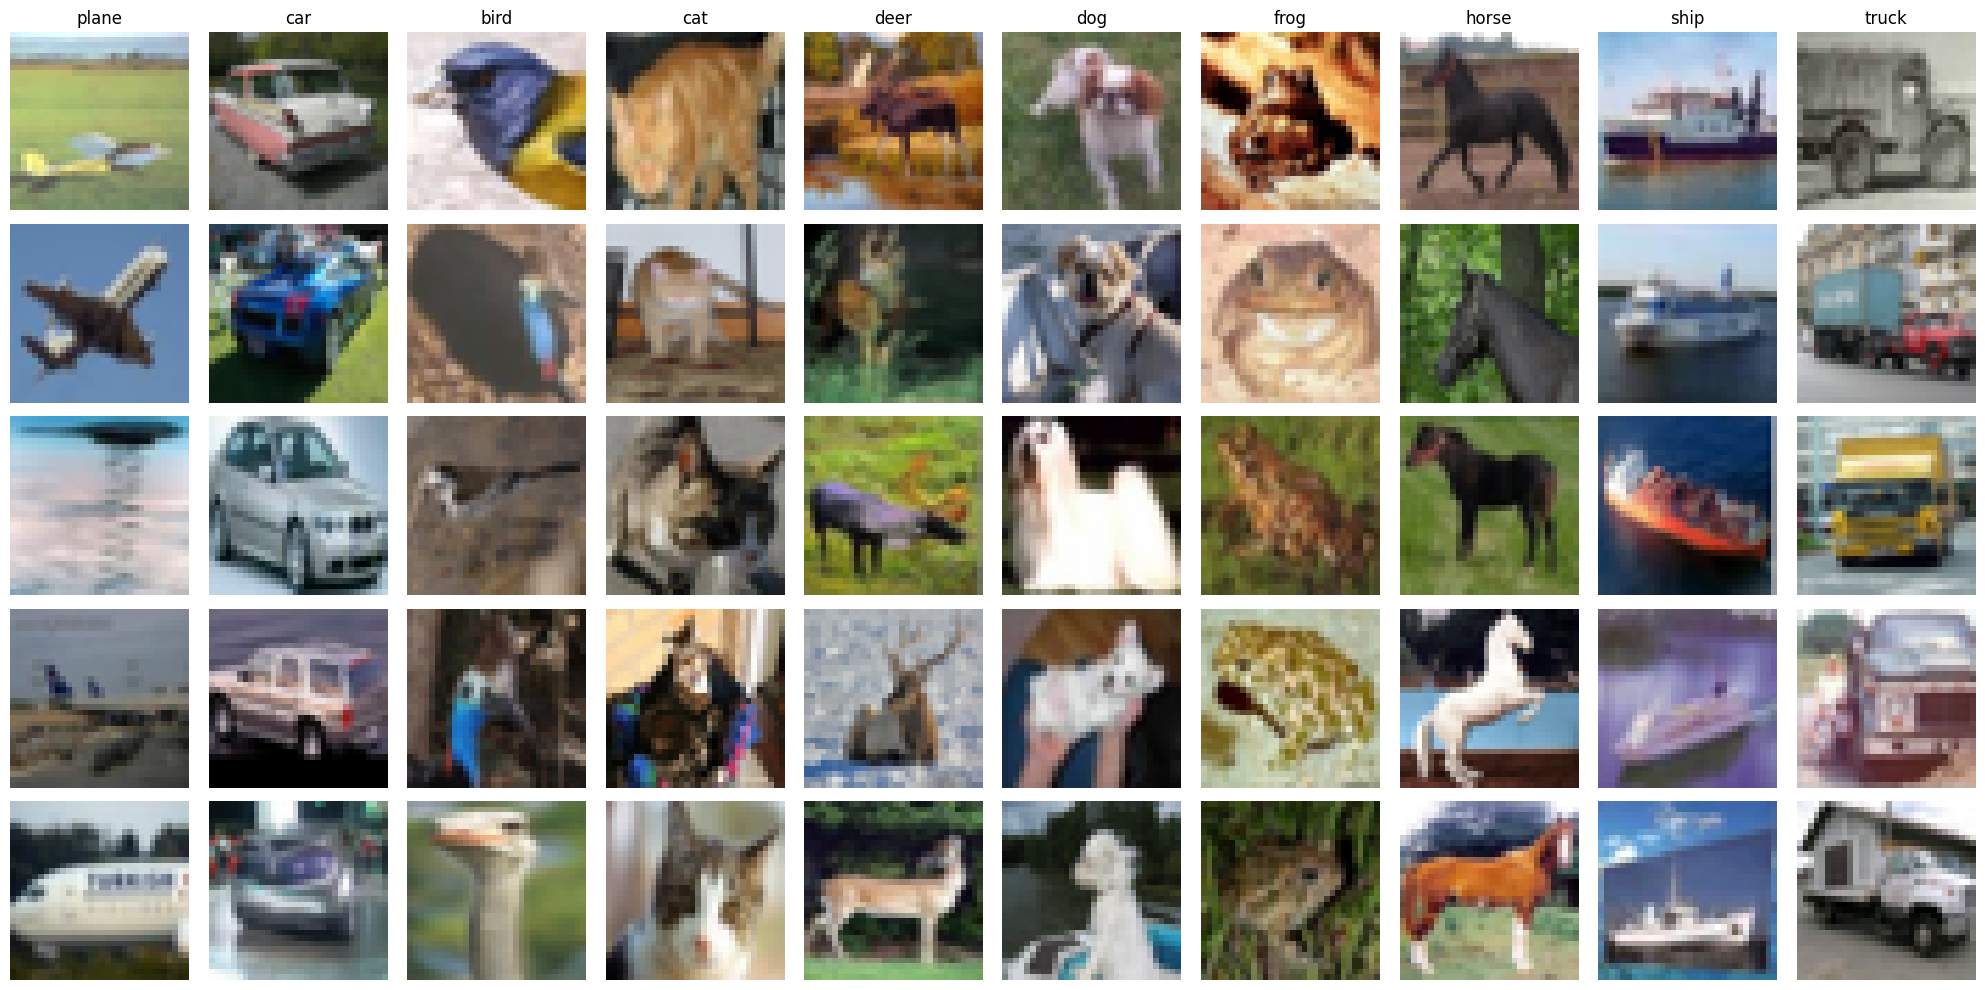

In [15]:
n_rows = n_examples 
n_cols = len(classes)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))

for col in range(n_cols):
    for row in range(n_rows):
        img = examples_dict[col][row]

        # unnormalize
        img = img / 2 + 0.5         # from [-1,1] to [0,1]

        # CHW -> HWC
        img_to_show = img.permute(1, 2, 0)      # imshow wants HWC

        # Selecting the row and the col
        ax = axes[row, col]

        # plotting
        ax.imshow(img_to_show)

        ax.axis('off')

        if row == 0:
            ax.set_title(classes[col])

plt.tight_layout()
plt.show()


## Model

Define your model here from scratch (You are not allowed to use the existing models in pytorch)

**NOTICE:** The model that you will have defined outputs a vector containing 10 numbers (for each class). Define a "feature space" that is a vector of size *N* (where *N > 10*) right before the last layer (You can then have a last layer like `nn.Linear(N, 10)`). See the image below to get a better understanding. We will use this later (we want to access the feature space of a sample when the sample is given to the model). The model tries to learn a representation of the samples in this feature space and we will see how good it could do this in later sections.

![Feature Space In Neural Network](https://i.postimg.cc/28Qjcn9D/feature-space-vis.png)

- **Hint I**: Our goal is to get accuracy above *90%* on testset. Our suggestion is to implement ResNet (ResNet18 could be a viable choice)
  - You can learn the network's structure and implementation online (Youtube, ...) and then implmenet it yourself and make changes to enhance it's performance on our task **(YOU SHOULD NOT COPY THE CODE!!! OTHERWISE, YOU'LL BE PENALIZED!!!)**

- **Hint II**: When defining your model, pay attension to the **NOTICE** part in the above. It's also better to read the "Exploring the feature space" section beforehand.  

In [15]:
import torch
import torch.nn as nn

class BasicBlock(nn.Module):
    def __init__(self, input_channels, out_channels = [32 , 64, 128, 256], stride=1):
        super(BasicBlock, self).__init__()

        # first feature map
        self.conv1 = nn.Conv2d(
            input_channels,
            out_channels[0],
            kernel_size=3, stride=stride, padding=0, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels[0])
        self.relu = nn.ReLU(inplace=True)

        # second feature map
        self.conv2 = nn.Conv2d(
            out_channels[0],
            (out_channels[1]),
            kernel_size=3, stride=1, padding=0, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels[1])

        # third feature map
        self.conv3 = nn.Conv2d(
            (out_channels[1]),
            (out_channels[2]),
            kernel_size=3, stride=stride, padding=0, bias=False
        )
        self.bn3 = nn.BatchNorm2d(out_channels[2])

        # fourth feature map
        self.conv4 = nn.Conv2d(
            (out_channels[2]),
            (out_channels[3]),
            kernel_size=3, stride=stride, padding=0, bias=False
        )
        self.bn4 = nn.BatchNorm2d(out_channels[3])

        # pooling layer
        self.pool = nn.AdaptiveAvgPool2d((1,1))

        # fully connected layer
        self.linear = nn.Linear(
            (out_channels[3]),
            10,
            bias=False
        )

 


    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)
        out = self.relu(out)

        out = self.conv4(out)
        out = self.bn4(out)
        out = self.relu(out)

        out = self.pool(out)
        out = torch.flatten(out , 1)

        out = self.linear(out)
        

        return out


## Train

In [17]:
X_train.shape

torch.Size([40000, 3, 32, 32])

### Model instantiation

Create an instance of your model and move it to `device`

In [18]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1650 Ti


In [19]:
y_train.shape

torch.Size([40000])

In [30]:
# TODO: Define Model
model = BasicBlock(X_train.shape[1]).to(device)
X_train , y_train = X_train.to(device) , y_train.to(device)
X_valid , y_valid = X_valid.to(device) , y_valid.to(device)
X_test , y_test = X_test.to(device) , y_test.to(device)

In [21]:
print(model.conv1)

Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)


In [22]:
print(next(model.parameters()).device)
print(torch.cuda.memory_allocated() / 1024**2, "MB")

cuda:0
706.7099609375 MB


In [23]:
model

BasicBlock(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (linear): Linear(in_features=256, out_features=10, bias=False)
)

In [24]:
X_train.device

device(type='cuda', index=0)

### Criterion & Optimizater

Define `criterion` and `optimizer` (Or `scheduler`)

In [31]:
# TODO: Define Loss and Optimizer
from torch import optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

### Train loop

Train your model

Tasks:
- [ ] Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- [ ] save train/validation loss and accuracy (of each epoch) in an array for later usage

In [26]:
# TODO: Implement Training Loop
# TODO: Implement Validation Loop

# adding the progress bar
from tqdm.auto import tqdm
# Function to train the model

def train_model(
        model, train_loader, validation_loader, num_epochs=50):
    
    #########################################
    # for reining and validation outputs ####
    #########################################
    train_dict = {
        "loss": [],
        "accuracy": []
    }
    validation_dict = {
        "loss": [],
        "accuracy": []
    }
    ############################
    # Training loop ############
    ############################

    for epoch in range(1,num_epochs+1):
        epoch_loss = 0.0
        valid_epoch_loss = 0.0
        model.train()
        total = 0
        correct = 0

        train_bar = tqdm(
            train_loader,
            desc=f"Epoch [{epoch}/{num_epochs}]",
            leave=True,
            colour="green"
        )

        for batch_x, batch_y in train_bar:
            
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            
            optimizer.zero_grad(set_to_none=True)   #avoiding congestion

            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

            pred = outputs.argmax(dim=1)   # getting the highest prob for class
            correct += (pred == batch_y).sum().item()
            total += batch_y.size(0)

            train_bar.set_postfix({
                "Loss": f"{loss.item():.4f}",
                "Acc": f"{correct / total:.4f}"
            })
        train_bar.close()
        avg_loss = epoch_loss / len(train_loader)
        train_dict["loss"].append(avg_loss)
        accuracy = correct / total
        train_dict["accuracy"].append(accuracy)
        
        #####################
        # validation loop ###
        #####################

        model.eval()
        valid_epoch_loss = 0.0
        valid_correct = 0
        valid_total = 0

        valid_bar = tqdm(
            validation_loader,
            desc="Validation",
            leave=False,
            colour="blue"
        )

        with torch.no_grad():
            for batch_x_valid , batch_y_valid in valid_bar:
                
                batch_x_valid , batch_y_valid = batch_x_valid.to(device) , batch_y_valid.to(device)

                valid_outputs = model(batch_x_valid)

                valid_loss = criterion(valid_outputs, batch_y_valid)

                valid_epoch_loss += valid_loss.item()

                valid_pred = valid_outputs.argmax(dim=1)
                valid_correct += (valid_pred == batch_y_valid).sum().item()
                valid_total += batch_y_valid.size(0)

                valid_bar.set_postfix({
                    "Loss": f"{valid_loss.item():.4f}",
                    "Acc": f"{valid_correct / valid_total:.4f}"
                })
        valid_bar.close()
        avg_valid_loss = valid_epoch_loss / len(validation_loader)
        validation_dict["loss"].append(avg_valid_loss)
        valid_accuracy = valid_correct / valid_total
        validation_dict["accuracy"].append(valid_accuracy)

        tqdm.write(
            f"Epoch [{epoch:02d}/{num_epochs}] | "
            f"Train Loss: {avg_loss:.4f} | "
            f"Train Acc: {accuracy:.4f} | "
            f"Val Loss: {avg_valid_loss:.4f} | "
            f"Val Acc: {valid_accuracy:.4f}"
        )

    return train_dict , validation_dict

c:\Users\hossein\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
train_dict , validation_dict = train_model(model , train_loader=trainloader,
                                           validation_loader=validationloader)

Epoch [1/50]: 100%|██████████| 625/625 [00:28<00:00, 21.92it/s, Loss=1.0013, Acc=0.4768]


Epoch [01/50] | Train Loss: 1.4402 | Train Acc: 0.4768 | Val Loss: 1.5485 | Val Acc: 0.4388


Epoch [2/50]: 100%|██████████| 625/625 [00:27<00:00, 22.43it/s, Loss=1.1711, Acc=0.5950]


Epoch [02/50] | Train Loss: 1.1377 | Train Acc: 0.5950 | Val Loss: 1.1239 | Val Acc: 0.5988


Epoch [3/50]: 100%|██████████| 625/625 [00:27<00:00, 22.34it/s, Loss=0.9807, Acc=0.6461]


...

Epoch [48/50] | Train Loss: 0.1363 | Train Acc: 0.9545 | Val Loss: 0.8740 | Val Acc: 0.7701


Epoch [49/50]: 100%|██████████| 625/625 [00:30<00:00, 20.61it/s, Loss=0.0845, Acc=0.9527]


Epoch [49/50] | Train Loss: 0.1396 | Train Acc: 0.9527 | Val Loss: 1.0353 | Val Acc: 0.7561


Epoch [50/50]: 100%|██████████| 625/625 [00:30<00:00, 20.72it/s, Loss=0.1680, Acc=0.9534]
                                                                                      c=0.7848]

Epoch [50/50] | Train Loss: 0.1344 | Train Acc: 0.9534 | Val Loss: 0.8712 | Val Acc: 0.7848


In [28]:
train_dict

{'loss': [1.4401684737205505,
  1.1376950201034546,
  1.0043297269821168,
  0.9134596725463867,
  0.8473464524269104,
  0.7959234792709351,
  0.7521034949302673,
  0.7141788342475891,
  0.6767388350963592,
  0.6510012829303742,
  0.6178125460147857,
  0.5948370435237884,
  0.5676321615695953,
  0.5420421326637268,
  0.5242558284521103,
  0.5030769548416137,
  0.48343193187713623,
  0.4670454592704773,
  0.44510791528224947,
  0.43335422575473787,
  0.4187866576194763,
  0.3972413702487946,
  0.3854110762119293,
  0.37079520463943483,
  0.35767789795398713,
  0.3399854593515396,
  0.329777666926384,
  0.31723756633996963,
  0.3038687074542046,
  0.2933093062877655,
  0.2909506909966469,
  0.2703746932864189,
  0.26078336188793183,
  0.24557601178884506,
  0.24111029961109162,
  0.228866450715065,
  0.22052472784519195,
  0.21058725743293763,
  0.20724239939451217,
  0.1934781545639038,
  0.19202416759729385,
  0.1826610878586769,
  0.17563208975195885,
  0.16378157571554183,
  0.1686063

In [29]:
validation_dict

{'loss': [1.5485087473681018,
  1.1238740154892017,
  1.0545954020919315,
  1.07519503156091,
  0.8579612955166276,
  1.1744898569052387,
  0.995913169186586,
  0.8393019957906881,
  0.7782048590623649,
  0.8048923666689806,
  0.6944119869523747,
  0.7765422372301672,
  0.820554064337615,
  0.7553116681089826,
  0.6807096108889125,
  0.7747417437802454,
  0.7795785646529714,
  0.7822345943207953,
  0.7549350202842883,
  0.7258257584966672,
  0.6495331180323461,
  0.7463324698293285,
  0.723352267294173,
  0.7111157297518602,
  0.7181143525299752,
  0.7294846469429648,
  0.6806518002680153,
  0.8348123655197727,
  0.7700444321343853,
  0.7997545968195435,
  0.8107940547025887,
  0.774485144076074,
  0.7399150023035183,
  1.304693591442837,
  0.8659305464310251,
  0.7559652236426712,
  0.8938343597065871,
  0.7003300015334111,
  0.7470720636237199,
  0.8989005745596187,
  0.9544969743983761,
  0.8044452521072072,
  1.1442754991874573,
  0.9966937364286678,
  0.8156307461155448,
  0.82049

In [30]:
import pandas as pd

train_df = pd.DataFrame(train_dict)
valid_df = pd.DataFrame(validation_dict)

In [31]:
result = pd.concat([train_df, valid_df], axis=1)
print(f"    training df \t\tvalidation df")
print(result)

    training df 		validation df
        loss  accuracy      loss  accuracy
0   1.440168  0.476775  1.548509    0.4388
1   1.137695  0.594975  1.123874    0.5988
2   1.004330  0.646125  1.054595    0.6299
3   0.913460  0.679100  1.075195    0.6224
4   0.847346  0.703525  0.857961    0.7005
5   0.795923  0.722200  1.174490    0.6002
6   0.752103  0.739000  0.995913    0.6731
7   0.714179  0.751075  0.839302    0.7118
8   0.676739  0.765600  0.778205    0.7329
9   0.651001  0.773750  0.804892    0.7251
10  0.617813  0.787150  0.694412    0.7579
11  0.594837  0.794975  0.776542    0.7338
12  0.567632  0.803075  0.820554    0.7207
13  0.542042  0.811875  0.755312    0.7448
14  0.524256  0.820575  0.680710    0.7697
15  0.503077  0.826175  0.774742    0.7444
16  0.483432  0.832975  0.779579    0.7392
17  0.467045  0.838800  0.782235    0.7434
18  0.445108  0.846950  0.754935    0.7509
19  0.433354  0.851450  0.725826    0.7582
20  0.418787  0.855200  0.649533    0.7872
21  0.397241  0.862950

### Save Model & Dataframes

Since changes need to be made to the model later on, it is advisable to save your model to avoid having to retrain it in case of any issues.

In [32]:
from pathlib import Path

# Create directory
root = Path("Results")
(root / "Models").mkdir(parents=True, exist_ok=True)
(root / "Dataframes").mkdir(parents=True, exist_ok=True)

checkpoint = {

    # Resume Training
    "epoch": 50,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    # Metrics
    "train_loss": train_dict["loss"][-1],
    "train_accuracy": train_dict["accuracy"][-1],
    "validation_loss": validation_dict["loss"][-1],
    "validation_accuracy": validation_dict["accuracy"][-1],

    # Hyperparameters
    "batch_size": 64,
    "learning_rate": 0.001,
    "num_classes": len(classes),

}

torch.save(
    checkpoint,
    root / "Models" / "cifar10_Q1_checkpoint.pth"
)

In [33]:
train_df.to_excel(root / "Dataframes" /'cifar10_Q1_Classification_train_df.xlsx', index= False)
valid_df.to_excel(root / "Dataframes" /'cifar10_Q1_Classification_valid_df.xlsx', index= False)

if you **stopped the python kernel** or **shut down the PC** after the model run (just like me), and ***dont want to retrain*** the model and have the results; the following codes are for this mean:

### Loading Dataframes

In [35]:
import pandas as pd
train_df , valid_df = pd.read_excel(root / "Dataframes" /'cifar10_Q1_Classification_train_df.xlsx') ,pd.read_excel(root / "Dataframes" /'cifar10_Q1_Classification_valid_df.xlsx')

train_dict , valid_dict = train_df.to_dict() , valid_df.to_dict()
print(f"train_dict: {train_dict}")
print(f"valid_dict: {valid_dict}")

train_dict: {'loss': {0: 1.44016847372055, 1: 1.137695020103455, 2: 1.004329726982117, 3: 0.9134596725463867, 4: 0.8473464524269104, 5: 0.7959234792709351, 6: 0.7521034949302673, 7: 0.7141788342475891, 8: 0.6767388350963592, 9: 0.6510012829303742, 10: 0.6178125460147857, 11: 0.5948370435237884, 12: 0.5676321615695953, 13: 0.5420421326637268, 14: 0.5242558284521103, 15: 0.5030769548416137, 16: 0.4834319318771362, 17: 0.4670454592704773, 18: 0.4451079152822495, 19: 0.4333542257547379, 20: 0.4187866576194763, 21: 0.3972413702487946, 22: 0.3854110762119293, 23: 0.3707952046394348, 24: 0.3576778979539871, 25: 0.3399854593515396, 26: 0.329777666926384, 27: 0.3172375663399696, 28: 0.3038687074542046, 29: 0.2933093062877655, 30: 0.2909506909966469, 31: 0.2703746932864189, 32: 0.2607833618879318, 33: 0.2455760117888451, 34: 0.2411102996110916, 35: 0.228866450715065, 36: 0.2205247278451919, 37: 0.2105872574329376, 38: 0.2072423993945122, 39: 0.1934781545639038, 40: 0.1920241675972938, 41: 0.1826

### Loading Model

In [37]:
model = BasicBlock(input_channels=3).to(device)

checkpoint = torch.load(
    root / "Models" / "cifar10_Q1_checkpoint.pth",
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

epoch = checkpoint["epoch"]

train_loss = checkpoint["train_loss"]
train_accuracy = checkpoint["train_accuracy"]

validation_loss = checkpoint["validation_loss"]
validation_accuracy = checkpoint["validation_accuracy"]

model.eval()

BasicBlock(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (linear): Linear(in_features=256, out_features=10, bias=False)
)

### till here!

### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

In [38]:
train_dict

{'loss': {0: 1.44016847372055,
  1: 1.137695020103455,
  2: 1.004329726982117,
  3: 0.9134596725463867,
  4: 0.8473464524269104,
  5: 0.7959234792709351,
  6: 0.7521034949302673,
  7: 0.7141788342475891,
  8: 0.6767388350963592,
  9: 0.6510012829303742,
  10: 0.6178125460147857,
  11: 0.5948370435237884,
  12: 0.5676321615695953,
  13: 0.5420421326637268,
  14: 0.5242558284521103,
  15: 0.5030769548416137,
  16: 0.4834319318771362,
  17: 0.4670454592704773,
  18: 0.4451079152822495,
  19: 0.4333542257547379,
  20: 0.4187866576194763,
  21: 0.3972413702487946,
  22: 0.3854110762119293,
  23: 0.3707952046394348,
  24: 0.3576778979539871,
  25: 0.3399854593515396,
  26: 0.329777666926384,
  27: 0.3172375663399696,
  28: 0.3038687074542046,
  29: 0.2933093062877655,
  30: 0.2909506909966469,
  31: 0.2703746932864189,
  32: 0.2607833618879318,
  33: 0.2455760117888451,
  34: 0.2411102996110916,
  35: 0.228866450715065,
  36: 0.2205247278451919,
  37: 0.2105872574329376,
  38: 0.207242399394

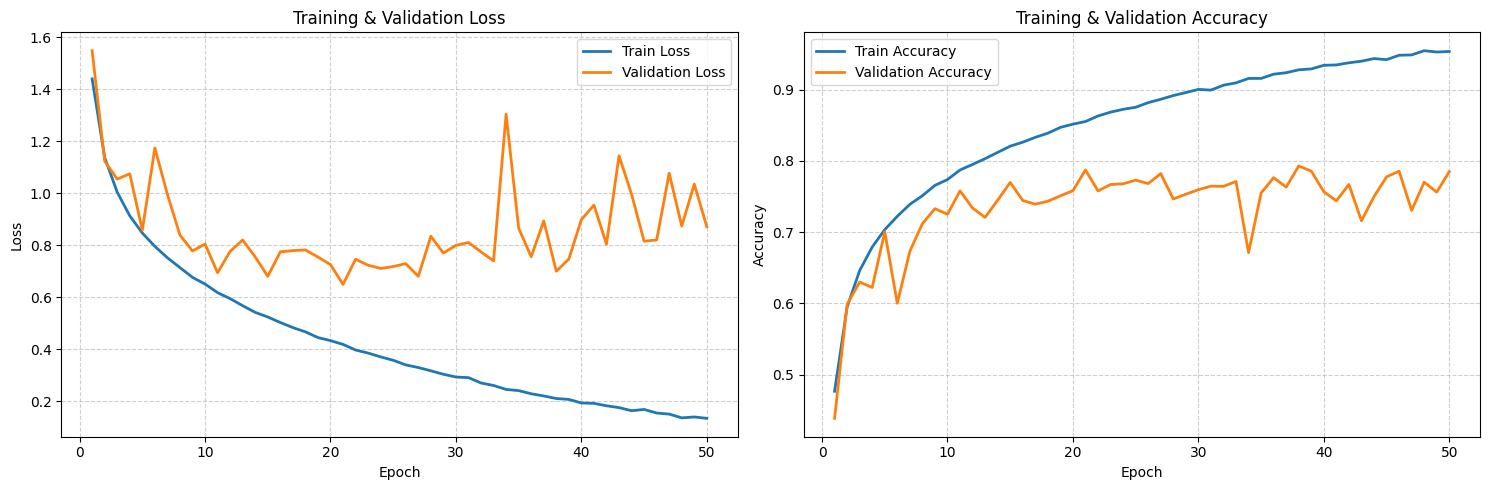

In [39]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_dict["loss"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ==========================
# Loss
# ==========================
ax[0].plot(epochs, train_df["loss"], label="Train Loss", linewidth=2)
ax[0].plot(epochs, valid_df["loss"], label="Validation Loss", linewidth=2)

ax[0].set_title("Training & Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, linestyle="--", alpha=0.6)
ax[0].legend()

# ==========================
# Accuracy
# ==========================
ax[1].plot(epochs, train_df["accuracy"], label="Train Accuracy", linewidth=2)
ax[1].plot(epochs, valid_df["accuracy"], label="Validation Accuracy", linewidth=2)

ax[1].set_title("Training & Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, linestyle="--", alpha=0.6)
ax[1].legend()

plt.tight_layout()
plt.show()

## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy above `90%`

In [40]:
model.eval()
test_dict = {
    "loss":[],
    "accuracy":[]
}
test_epoch_loss = 0.0
test_correct = 0
test_total = 0
for batch_x_test , batch_y_test in testloader:
            
    batch_x_test , batch_y_test = batch_x_test.to(device) , batch_y_test.to(device)

    test_outputs = model(batch_x_test)

    test_loss = criterion(test_outputs, batch_y_test)

    test_epoch_loss += test_loss.item()

    test_pred = test_outputs.argmax(dim=1)
    test_correct += (test_pred == batch_y_test).sum().item()
    test_total += batch_y_test.size(0)

    avg_test_loss = test_epoch_loss / len(testloader)
    test_dict["loss"].append(avg_test_loss)
    test_accuracy = test_correct / test_total
    test_dict["accuracy"].append(test_accuracy)

In [41]:
test_df = pd.DataFrame(test_dict)
test_df.to_excel(root / "Dataframes" /'cifar10_Q1_Classification_test_df.xlsx' , index=False)
test_df

,loss,accuracy
0,0.006126,0.796875
1,0.009788,0.820312
2,0.013568,0.817708
3,0.018595,0.820312
4,0.026605,0.806250
...,...,...
152,0.878469,0.776654
153,0.885265,0.776278
154,0.891567,0.776613
155,0.898898,0.776342


### To achieve accuracy above 90%, the following solutions are recommended:
- Increase Epochs for training and add **Early Stopping**
- Increase the number of layers of our CNN architecture
- Increase the number of filters

## Visualize incorrectly predicted samples from testset

Visualize *24* random images from testset that are incorrectly predicted by the model. Note that if you used normalization in the transform function for loading the data, you will need to unnormalize the images before displaying them.

In [42]:
def get_misclassified_examples(model, test_loader,device='cuda'):
    model.eval()
        
    misclassified_indices = []
    actual_labels = []
    predicted_labels = []
    global_idx = 0
    with torch.no_grad():
        for batch_x_test , batch_y_test in testloader:
            batch_x_test , batch_y_test = batch_x_test.to(device) , batch_y_test.to(device)  
            outputs = model(batch_x_test)
            test_pred = outputs.argmax(dim=1)  
            for i in range(len(batch_y_test)):
                actual = batch_y_test[i].item()
                predicted = test_pred[i].item()

                if actual != predicted:
                        misclassified_indices.append(global_idx)
                        actual_labels.append(actual)
                        predicted_labels.append(predicted)

                global_idx += 1

    wrong_test_df = pd.DataFrame(
        {
            'Image_Index': misclassified_indices,
            'Actual_Class': actual_labels,
            'Predicted_Class': predicted_labels
        }
        )
    return wrong_test_df

In [43]:
df_errors = get_misclassified_examples(model, testloader)

In [44]:
df_errors

,Image_Index,Actual_Class,Predicted_Class
0,1,8,1
1,3,0,8
2,6,1,9
3,9,1,9
4,24,5,4
...,...,...,...
2234,9986,8,0
2235,9989,2,4
2236,9991,0,8
2237,9995,8,0


In [45]:
df_errors["Image_Index"].loc[1]

np.int64(3)

In [46]:
X_test.shape

torch.Size([10000, 3, 32, 32])

In [47]:
X_test_visualize = X_test.to('cpu') # cuda version of test set can not be passed to numpy

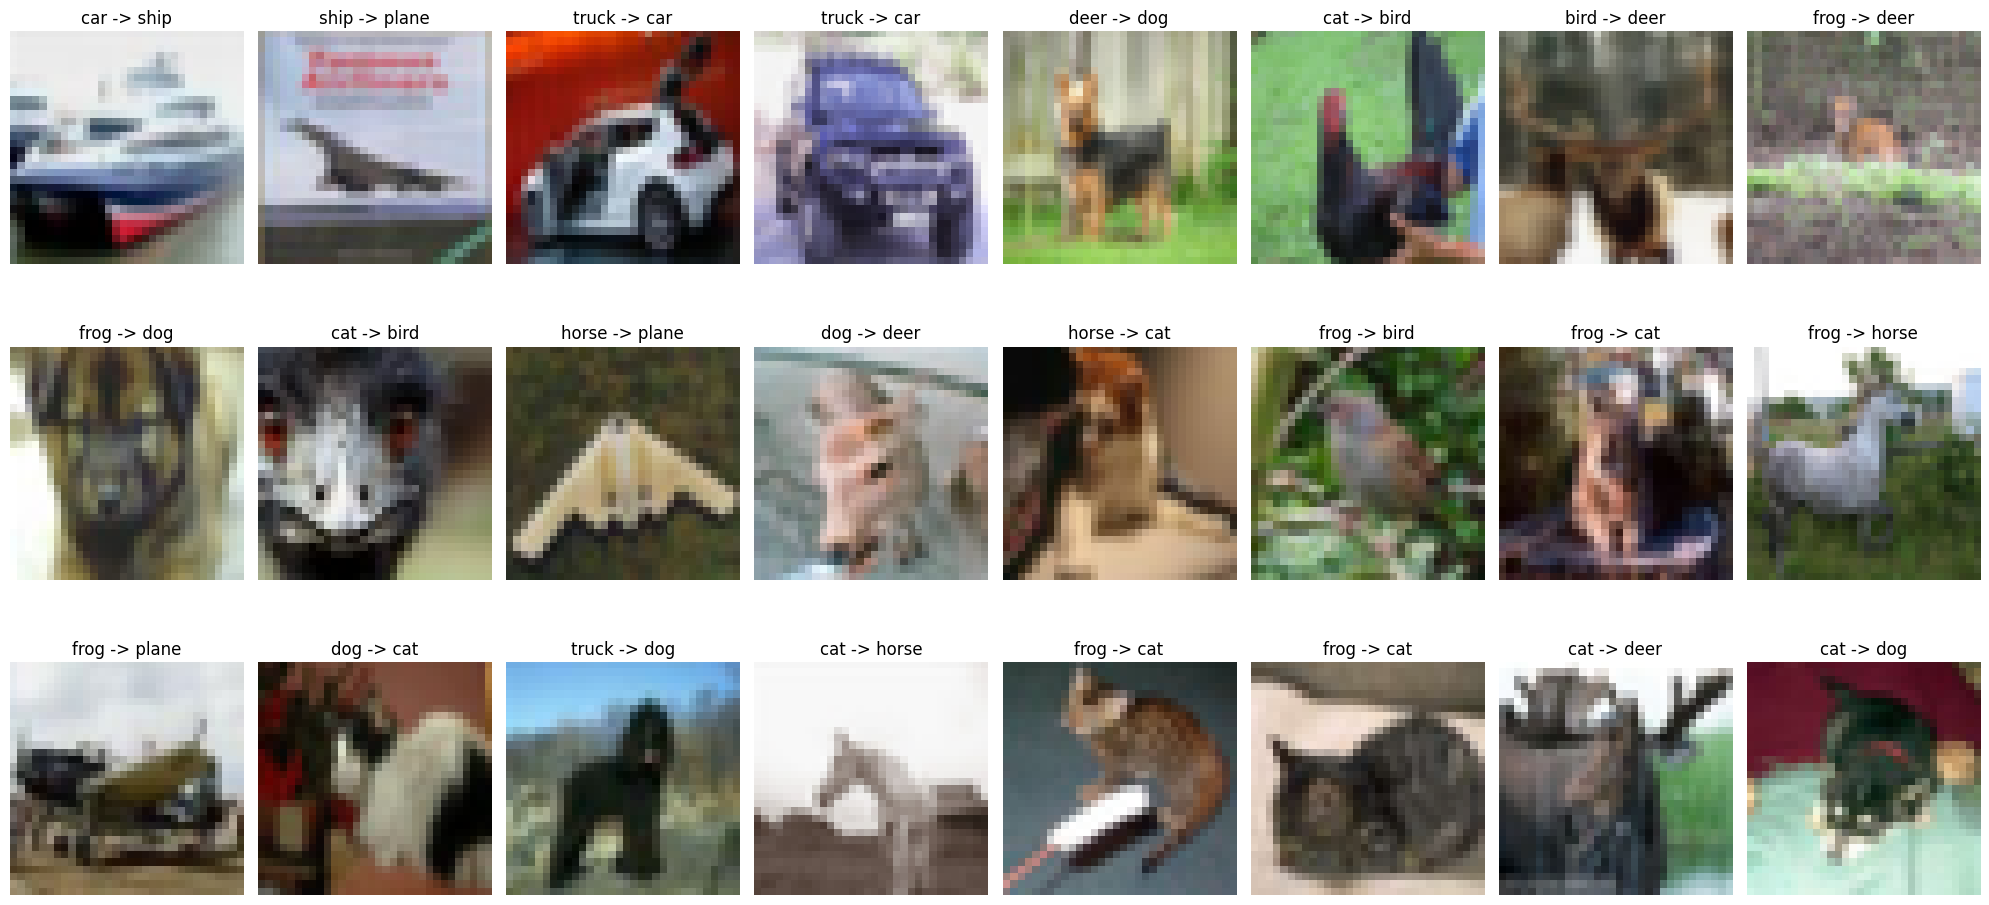

In [48]:
# TODO: Plot Samples with Wrong Predicted Classes

n_rows = 3 
n_cols = 8
total = n_rows * n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes_flat = axes.flat
for example in range(total):
    ax = axes_flat[example]
    img = X_test_visualize[df_errors["Image_Index"].loc[example]]

    # unnormalize
    img = img / 2 + 0.5         # from [-1,1] to [0,1]

    img = torch.clamp(img, 0, 1)
    # CHW -> HWC
    img_to_show = img.permute(1, 2, 0)      # imshow wants HWC

    # plotting
    ax.imshow(img_to_show)

    ax.axis('off')

    ax.set_title(
        f"{classes[df_errors['Predicted_Class'].loc[example]]} -> {classes[df_errors['Actual_Class'].loc[example]]}"
    )

plt.tight_layout()
plt.show()


## Exploring the feature space

### Calculate the feature space for all training samples

You have trained and evaluated your model. Now, for each sample in the trainset, calculate it's "feature space" discussed in the model section. The result of this section should be a tensor of size `(50000, N)` saved in a variable (for later usage)

- **Hint 1:** define a tensor with dimension `(50000, N)` where *50000* is the size of the trainset and *N* is the dimension of the feature space

- **Hint 2:** Pay attension to the `shuffle` attribute of your train dataloader (If needed)

In [49]:
model

BasicBlock(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (linear): Linear(in_features=256, out_features=10, bias=False)
)

first we need to gather a total training dataset (***including training and validation set***) based on the instruction of the section that said the input tensor should be (50000, N)  
                                     (***training = 40000 , validation = 10000***)

In [50]:
# TODO: Find Features and Put Them in One Dimensional List
from torch.utils.data import ConcatDataset, DataLoader

combined_dataset = ConcatDataset([
    train_dataset,
    validation_dataset
])

total_training = DataLoader(
    combined_dataset,
    batch_size=64,
    shuffle=False
)

In [51]:
len(total_training.dataset)

50000

In [52]:
from torchvision.models.feature_extraction import create_feature_extractor
import torch.nn.functional as F     # for global average pooling 

extractor = create_feature_extractor(
    model,
    return_nodes={"conv4": "features"}
)

extractor.eval()

all_features = []
all_labels = []

with torch.no_grad():
    for images, labels in total_training:

        images = images.to(device)

        out = extractor(images)

        features = out["features"]
        
        # Global Average Pooling [B, C, H, W] -> [B, C]
        out = F.adaptive_avg_pool2d(features, (1,1))

        
        # flatten
        out = torch.flatten(out, 1) # flatting the C dim to the end -> [B, (C x 1 x 1)]

        all_features.append(out.cpu())
        all_labels.append(labels)
    
    features = torch.cat(all_features)
    labels = torch.cat(all_labels)


In [53]:
print(f"""
features.shape: {features.shape}
labels.shape: {labels.shape}
""")


features.shape: torch.Size([50000, 256])
labels.shape: torch.Size([50000])



In [54]:
features[0].argmax()

tensor(52)

In [55]:
features[0][features[0].argmax()]

tensor(1.1819)

### K Nearest Neighbor in feature space

You already have calculated the feature spaces for trainset ($S$) in the previous section

1. Get 5 random samples from testset which are correctly predicted by the model.
2. for each sample, calculate it's "feature space" ($X$)
3. for each sample, calculate it's *5* nearest neighbors in "feature space" in the trainset (by comparing $X$ to each row in $S$) and visualize them

**Note:** Your visualization should be something like the below picture

**Hint:** To find the nearest neighbors in the feature space, you can use any library of your choice.

1. Get 5 random samples from testset which are correctly predicted by the model.

In [56]:
def get_right_classified_examples(model, test_loader, n_examples=10, device='cuda'):

    model.eval()

    right_classified_indices = []
    actual_labels = []
    predicted_labels = []

    global_idx = 0

    with torch.no_grad():

        for batch_x_test, batch_y_test in test_loader:

            batch_x_test = batch_x_test.to(device)
            batch_y_test = batch_y_test.to(device)

            outputs = model(batch_x_test)

            test_pred = outputs.argmax(dim=1)

            for i in range(len(batch_y_test)):

                actual = batch_y_test[i].item()
                predicted = test_pred[i].item()

                if actual == predicted:
                    right_classified_indices.append(global_idx)
                    actual_labels.append(actual)
                    predicted_labels.append(predicted)

                    if len(right_classified_indices) == n_examples:
                        break

                global_idx += 1

            if len(right_classified_indices) == n_examples:
                break


    right_test_df = pd.DataFrame(
        {
            'Image_Index': right_classified_indices,
            'Actual_Class': actual_labels,
            'Predicted_Class': predicted_labels
        }
    )

    return right_test_df
df_right_examples = get_right_classified_examples(model, test_loader=testloader , n_examples=5)
df_right_examples

,Image_Index,Actual_Class,Predicted_Class
0,0,3,3
1,2,8,8
2,4,6,6
3,5,6,6
4,7,6,6


In [57]:
X_top_5_test_img = []
y_top_5_test_img = []
for example in df_right_examples["Image_Index"]:
    X_top_5_test_img.append(X_test[example])
    y_top_5_test_img.append(y_test[example])

2. for each sample, calculate it's "feature space" ($X$)

In [58]:
X_test.shape

torch.Size([10000, 3, 32, 32])

In [59]:
df_right_examples["Image_Index"].values

array([0, 2, 4, 5, 7])

In [60]:
from torchvision.models.feature_extraction import create_feature_extractor
import torch.nn.functional as F

extractor = create_feature_extractor(
    model,
    return_nodes={"conv4": "features"}
).to(device)

extractor.eval()

idx = torch.tensor(df_right_examples["Image_Index"].values, dtype=torch.long)

images = X_test[idx].to(device)              # [5, 3, 32, 32]
labels = torch.tensor(
    df_right_examples["Actual_Class"].values,
    dtype=torch.long
)

with torch.no_grad():
    out = extractor(images)
    feature_maps = out["features"]           # [5, C, H, W]

    top5_test_features = F.adaptive_avg_pool2d(feature_maps, (1, 1))
    top5_test_features = torch.flatten(top5_test_features, 1)

top5_test_features = top5_test_features.cpu()

print(top5_test_features.shape)
print(labels.shape)

torch.Size([5, 256])
torch.Size([5])


3. for each sample, calculate it's *5* nearest neighbors in "feature space" in the trainset (by comparing $X$ to each row in $S$) and visualize them

In [61]:
features.shape

torch.Size([50000, 256])

In [62]:
def finding_kNN_features(training_set_features, test_set_features, k_nearest_neighbours = 5):
    dist = torch.cdist(
        test_set_features, # test set features
        training_set_features            # training set features
    )
    distances, indices = torch.topk(
        dist,
        k=k_nearest_neighbours,
        largest=False
    )
    return distances, indices

In [63]:
distances, indices = finding_kNN_features(
    training_set_features=features,
    test_set_features=top5_test_features
)
print(distances)
print(indices)


tensor([[3.0813, 3.4701, 3.6652, 3.7004, 3.7335],
        [3.5325, 3.5554, 3.5823, 3.6247, 3.6340],
        [3.3802, 3.4061, 3.4577, 3.6324, 3.6619],
        [2.4638, 2.8031, 2.8428, 2.8880, 2.9609],
        [2.8612, 3.0438, 3.2313, 3.2530, 3.3085]])
tensor([[16587, 36093, 26349,  3438, 39075],
        [ 3568, 48567, 10723, 39895,  5458],
        [40569, 40156, 11125,  6605,  6763],
        [38457, 13681, 11307, 16645, 41946],
        [31937, 45354,  3054, 40924, 15768]])


In [64]:
X_train_visualize = X_train.to('cpu')
X_valid_visualize = X_valid.to('cpu')

In [65]:
X_train_visualize.shape

torch.Size([40000, 3, 32, 32])

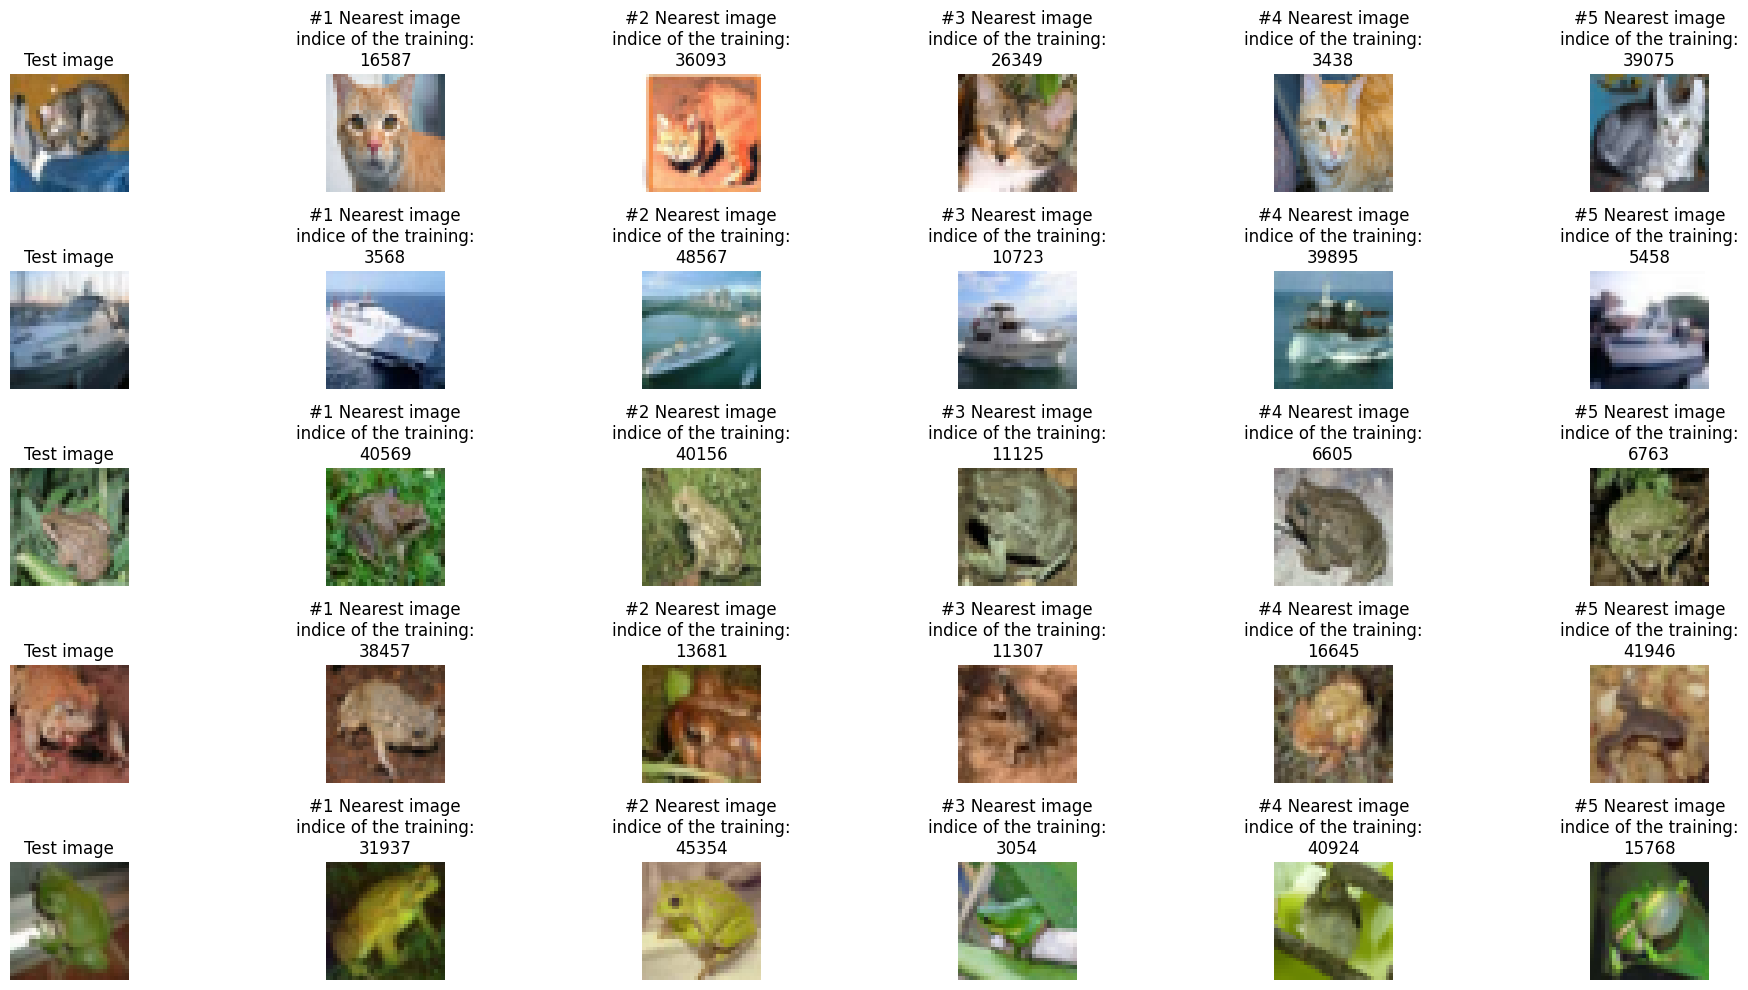

In [66]:
n_rows = indices.shape[0]
n_cols =  indices.shape[1] + 1
total = n_rows * n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes_flat = axes.flat
for col in range(n_cols):
    if col == 0:        # for only the first column
        for row in range(n_rows):
            img = X_test_visualize[df_right_examples["Image_Index"].loc[row]]       

            # unnormalize
            img = img / 2 + 0.5         # from [-1,1] to [0,1]

            img = torch.clamp(img, 0, 1)
            # CHW -> HWC
            img_to_show = img.permute(1, 2, 0)      # imshow wants HWC
            ax = axes[row, col]
            # plotting
            ax.imshow(img_to_show)

            ax.axis('off')

            ax.set_title("Test image")
    
    else:
        for row in range(n_rows):
            img_indice = indices[row , col-1].item()
            if img_indice > X_train_visualize.shape[0]:
                img_indice = img_indice - X_train_visualize.shape[0]
                img = X_valid_visualize[img_indice]

            else:
                img = X_train_visualize[indices[row, col-1].item()]

            # unnormalize
            img = img / 2 + 0.5         # from [-1,1] to [0,1]

            img = torch.clamp(img, 0, 1)
            # CHW -> HWC
            img_to_show = img.permute(1, 2, 0)      # imshow wants HWC
            ax = axes[row, col]
            # plotting
            ax.imshow(img_to_show)

            ax.axis('off')

            ax.set_title(
                f"#{col} Nearest image\nindice of the training:\n{indices[row , col-1]}"
            )

plt.tight_layout()
plt.show()



### TSNE

1. Sample $M$ ($2000$ would be enought) random samples from the trainset feature space (calculated in the above sections)
2. Now you a vector of size `(M, N)` where $N$ is the dimension of the feature space
3. Using TSNE reduce $N$ to $2$ (Now you have a vector of size `(M, 2)`)
4. Print the shape of the output

**Hint:** You can use `sklearn.manifold.TSNE`

1. Sample $M$ ($2000$ would be enought) random samples from the trainset feature space (calculated in the above sections)

2. Now you a vector of size `(M, N)` where $N$ is the dimension of the feature space


In [67]:
y_train.shape

torch.Size([40000])

In [68]:
y_valid.shape

torch.Size([10000])

In [69]:
torch.manual_seed(42)
M_indices = torch.randperm(features.shape[0])[:2000]
print(M_indices.shape)
M_features = features[M_indices]
print(M_features.shape)

# getting the labels
y_train_total = torch.concat((y_train , y_valid), dim=0)
print(y_train_total.shape)
label_M = y_train_total[M_indices]
print(label_M)
print(label_M.shape)

torch.Size([2000])
torch.Size([2000, 256])
torch.Size([50000])
tensor([7, 0, 0,  ..., 9, 0, 5], device='cuda:0')
torch.Size([2000])


3. Using TSNE reduce $N$ to $2$ (Now you have a vector of size `(M, 2)`)


4. Print the shape of the output


In [70]:
from sklearn.manifold import TSNE
M_features_2_embedded = TSNE(n_components=2, 
                             learning_rate='auto',
                             init='random', perplexity=3).fit_transform(M_features)

M_features_2_embedded.shape

(2000, 2)

Visualize the points in a 2D plane (Set color of each point based on it's class)

**Notice:** Your visualization should be something like the below image

**Hint:** Use `plt.scatter(x, y, c=labels)`

In [71]:
type(label_M)

torch.Tensor

In [72]:
label_M_visualize = label_M.to('cpu')

In [73]:
label_M_visualize

tensor([7, 0, 0,  ..., 9, 0, 5])

In [74]:
M_features_2_embedded.shape

(2000, 2)

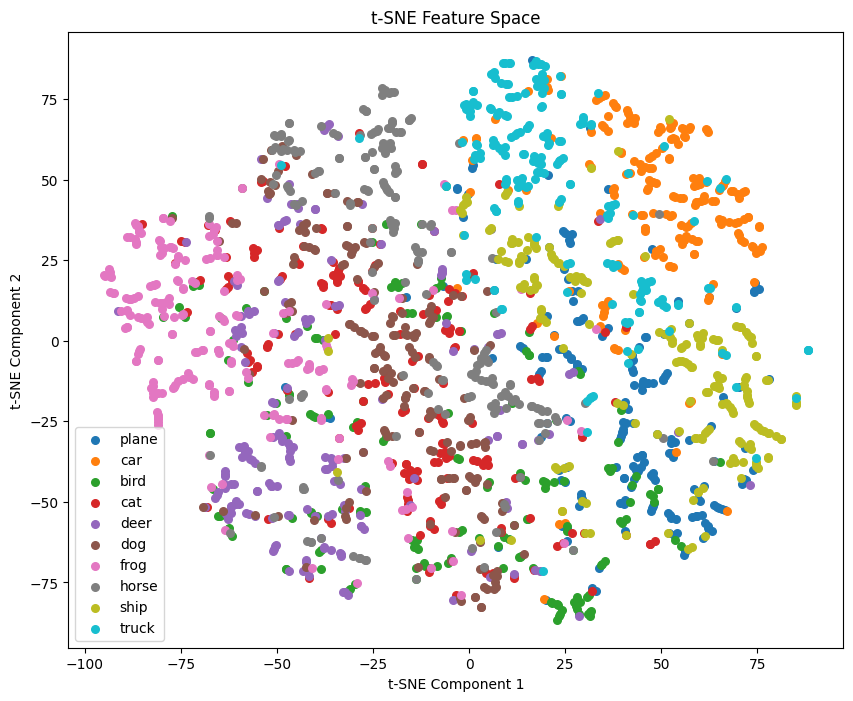

In [75]:
# TODO: Plot Results
plt.figure(figsize=(10, 8))

for cls in range(len(classes)):
    mask = (label_M_visualize == cls)

    plt.scatter(
        M_features_2_embedded[mask, 0],
        M_features_2_embedded[mask, 1],
        s=30,
        label=classes[cls]
    )

plt.legend()
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Feature Space")
plt.show()

> **Note**
>
> In the t-SNE visualization, the clusters corresponding to each class may not be as compact or well-separated as those shown in the professors' notebook. Consequently, the decision boundaries between classes may appear less distinct.
>
> This can be attributed to several factors:
>
> - The professors' model uses a larger number of convolutional filters, resulting in a richer feature representation.
> - Their model was trained for more epochs, allowing it to learn more discriminative features.
> - Overall, their network has a higher learning capacity and produces a more informative feature space.
>
> **In summary:** Our model is relatively simpler and less expressive, which leads to feature representations that are not as well separated in the embedding space.

### Feature Map


In this part, we are going to visualize the output of one of the convolutional layers to see what features they focus on.

First, let's select a random image from dataset.

tensor([1753])
torch.Size([3, 32, 32])


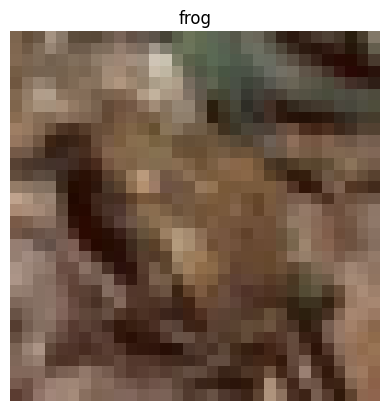

In [76]:
# TODO: Select an Image
torch.manual_seed(21)
idx = torch.randint(0, X_test.shape[0] , size=(1,))
print(idx)
# visualizing
X_test_example = X_test_visualize[idx]
img = X_test_example.squeeze(0) #removing the batch dim
print(img.shape)
img = img / 2 + 0.5              
img = torch.clamp(img, 0, 1)

img = img.permute(1, 2, 0)       # [3,32,32] -> [32,32,3]
label = classes[y_test[idx]]

plt.imshow(img.cpu())
plt.title(label)
plt.axis("off")
plt.show()

Now, we are going to *clip* our model at different points to get different intermediate representation.
* Clip your model at least at one point and plot the filters output. You can use the output of first Resnet block.

In order to clip the model, you can use `model.children()` method. For example, to get output only after the first 2 layers, you can do:

```
clipped = nn.Sequential(
    *list(model.children())[:2]
)
intermediate_output = clipped(input)
```



In [77]:
X_test_example = X_test_example.to('cuda')

In [78]:
for idx, layer in enumerate(list(model.children())):
    print(f"#{idx} layer: {layer}")

#0 layer: Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
#1 layer: BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
#2 layer: ReLU(inplace=True)
#3 layer: Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
#4 layer: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
#5 layer: Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
#6 layer: BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
#7 layer: Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
#8 layer: BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
#9 layer: AdaptiveAvgPool2d(output_size=(1, 1))
#10 layer: Linear(in_features=256, out_features=10, bias=False)


In [79]:
layers = list(model.children())

clipped = nn.Sequential(
    layers[0],
    layers[3],
    layers[5],
    layers[7]
)
intermediate_output = clipped(X_test_example)
print(intermediate_output.shape)

torch.Size([1, 256, 24, 24])


In [80]:
X_test_example.shape

torch.Size([1, 3, 32, 32])

> **Note**
>
> in the previous cell, if you just select somtehing like this:
```python
clipped = nn.Sequential(
    layers[7]
)
intermediate_output = clipped(X_test_example)
print(intermediate_output.shape)
```
> you definitely gonna crash, because you are inputting an example of `torch.Size([1, 3, 32, 32])` size and then delivering it to the wrong feature mapping and channel wise filters

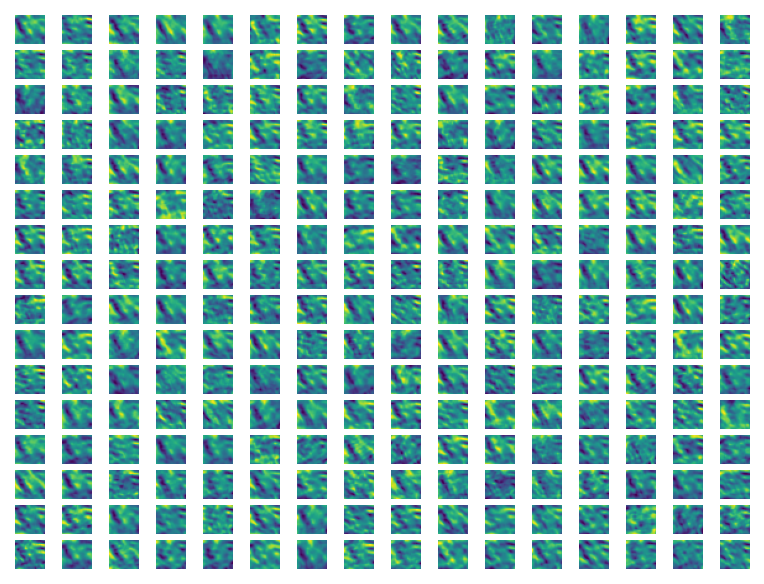

In [81]:
def plot_intermediate_output(result, title=None):
    """ Plots the intermediate output of shape
      N_FILTERS x H x W
    """
    plt.rcParams['figure.dpi'] = 150
    n_filters = result.shape[1]
    N = int(math.sqrt(n_filters))
    M = (n_filters + N - 1) // N
    assert N * M >= n_filters

    fig, axs = plt.subplots(N, M)
    fig.suptitle(title)

    for i in range(N):
        for j in range(M):
            if i*N + j < n_filters:
                axs[i][j].imshow(result[0, i*N + j].cpu().detach())
                axs[i][j].axis('off')

# TODO: Plot Intermediate Output
plot_intermediate_output(intermediate_output)

and another one with primative layers:

In [82]:
clipped = nn.Sequential(
    *list(layers[:5])
)
intermediate_output = clipped(X_test_example)
print(intermediate_output.shape)

torch.Size([1, 64, 28, 28])


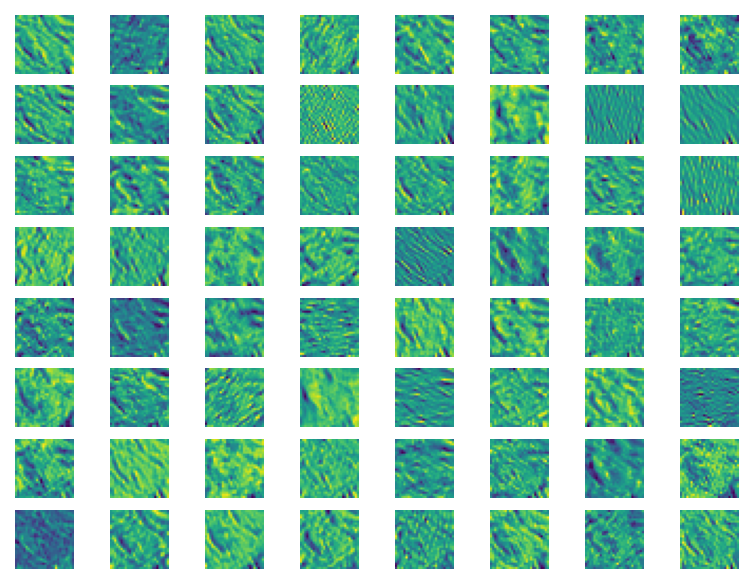

In [83]:
plot_intermediate_output(intermediate_output)

> **Note:**  
> we see that as a general rule that we studied in the theoritical part, the first layers of a deep conv layers, filters only recognise the abstract features, in another words they figure out simple patterns

## CIFAR100

In this section, we aim to test the trained model on a different dataset. For this purpose, we will use the CIFAR100 dataset, which is similar to CIFAR10 but has different types and numbers of classes. In order for the model to perform well on the new dataset, we need to modify the last layer of the model. As you know from the previous section, the last layer of the model is a linear layer that maps the features to the number of classes. In this section, due to the increase in the number of classes, we plan to modify this layer and train the new linear layer with the new dataset. Note that all other layers and weights of the model will remain fixed and unchanged; only the last layer will be retrained.

### Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms.

In [41]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# TODO: Load Train Data
trainset = datasets.CIFAR100(root="./data", train=True, download=True, transform=transform)     # if the dataset is not downloaded, make download=True


# TODO: Split Train and Validation Data

train_ratio = 0.8
validation_ratio = 0.2

train_size = int(train_ratio * len(trainset))
validation_size = int(validation_ratio * len(trainset))

train_dataset, validation_dataset = random_split(trainset, [train_size, validation_size])

# TODO: Load Test Data
testset = datasets.CIFAR100(root="./data", train=False, download=False, transform=transform)     # if the dataset is not downloaded, make download=False


# TODO: Define Data Loaders
trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
validationloader = DataLoader(validation_dataset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)



# seperating the X, y

def extract_dataset(dataset):
    images = []
    labels = []
    
    for img, label in dataset:
        images.append(img)
        labels.append(label)
    
    return torch.stack(images), torch.tensor(labels)

X_train, y_train = extract_dataset(train_dataset)
X_valid, y_valid = extract_dataset(validation_dataset)
X_test, y_test   = extract_dataset(testset)

In [42]:
print(f"X_train shape: {X_train.shape}") 
print(f"y_train shape: {y_train.shape}") 
print(f"X_valid shape: {X_valid.shape}") 
print(f"y_valid shape: {y_valid.shape}") 
print(f"X_test shape: {X_test.shape}") 
print(f"y_test shape: {y_test.shape}")

X_train shape: torch.Size([40000, 3, 32, 32])
y_train shape: torch.Size([40000])
X_valid shape: torch.Size([10000, 3, 32, 32])
y_valid shape: torch.Size([10000])
X_test shape: torch.Size([10000, 3, 32, 32])
y_test shape: torch.Size([10000])


In [7]:
len(torch.where(y_train==2)[0])

389

In [8]:
torch.where(y_train==2)[0][0]

tensor(57)

In [9]:
for no,index_2 in enumerate(torch.where(y_train==2)[0] , start=1):
    print(f"index no.{no} = {index_2}")

index no.1 = 57
index no.2 = 242
index no.3 = 279
index no.4 = 283
index no.5 = 425
index no.6 = 571
index no.7 = 622
index no.8 = 661
index no.9 = 701
index no.10 = 861
index no.11 = 1020
index no.12 = 1169
index no.13 = 1456
index no.14 = 1539
index no.15 = 1541
index no.16 = 1585
index no.17 = 1685
index no.18 = 1725
index no.19 = 1866
index no.20 = 2030
index no.21 = 2079
index no.22 = 2105
index no.23 = 2199
index no.24 = 2355
index no.25 = 2433
index no.26 = 2711
index no.27 = 2754
index no.28 = 2905
index no.29 = 3007
index no.30 = 3082
index no.31 = 3160
index no.32 = 3188
index no.33 = 3283
index no.34 = 3360
index no.35 = 3421
index no.36 = 3704
index no.37 = 3745
index no.38 = 3902
index no.39 = 3903
index no.40 = 3981
index no.41 = 4083
index no.42 = 4175
index no.43 = 4586
index no.44 = 4713
index no.45 = 4826
index no.46 = 5279
index no.47 = 5322
index no.48 = 5533
index no.49 = 5537
index no.50 = 5795
index no.51 = 5817
index no.52 = 5899
index no.53 = 6056
index no.54 =

In [10]:
X_train.shape

torch.Size([40000, 3, 32, 32])

In [11]:
y_train.shape

torch.Size([40000])

In [12]:
classes = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee",
    "beetle", "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee",
    "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur", "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine", "possum",
    "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor", "train",
    "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]
print(len(classes))

100


In [13]:
X_train[torch.where(y_train==2)[0][0]].shape

torch.Size([3, 32, 32])

### Visualization

Visualize 1 random images from each class.

- **Hint**:  You can use `plt.subplots` for visualization

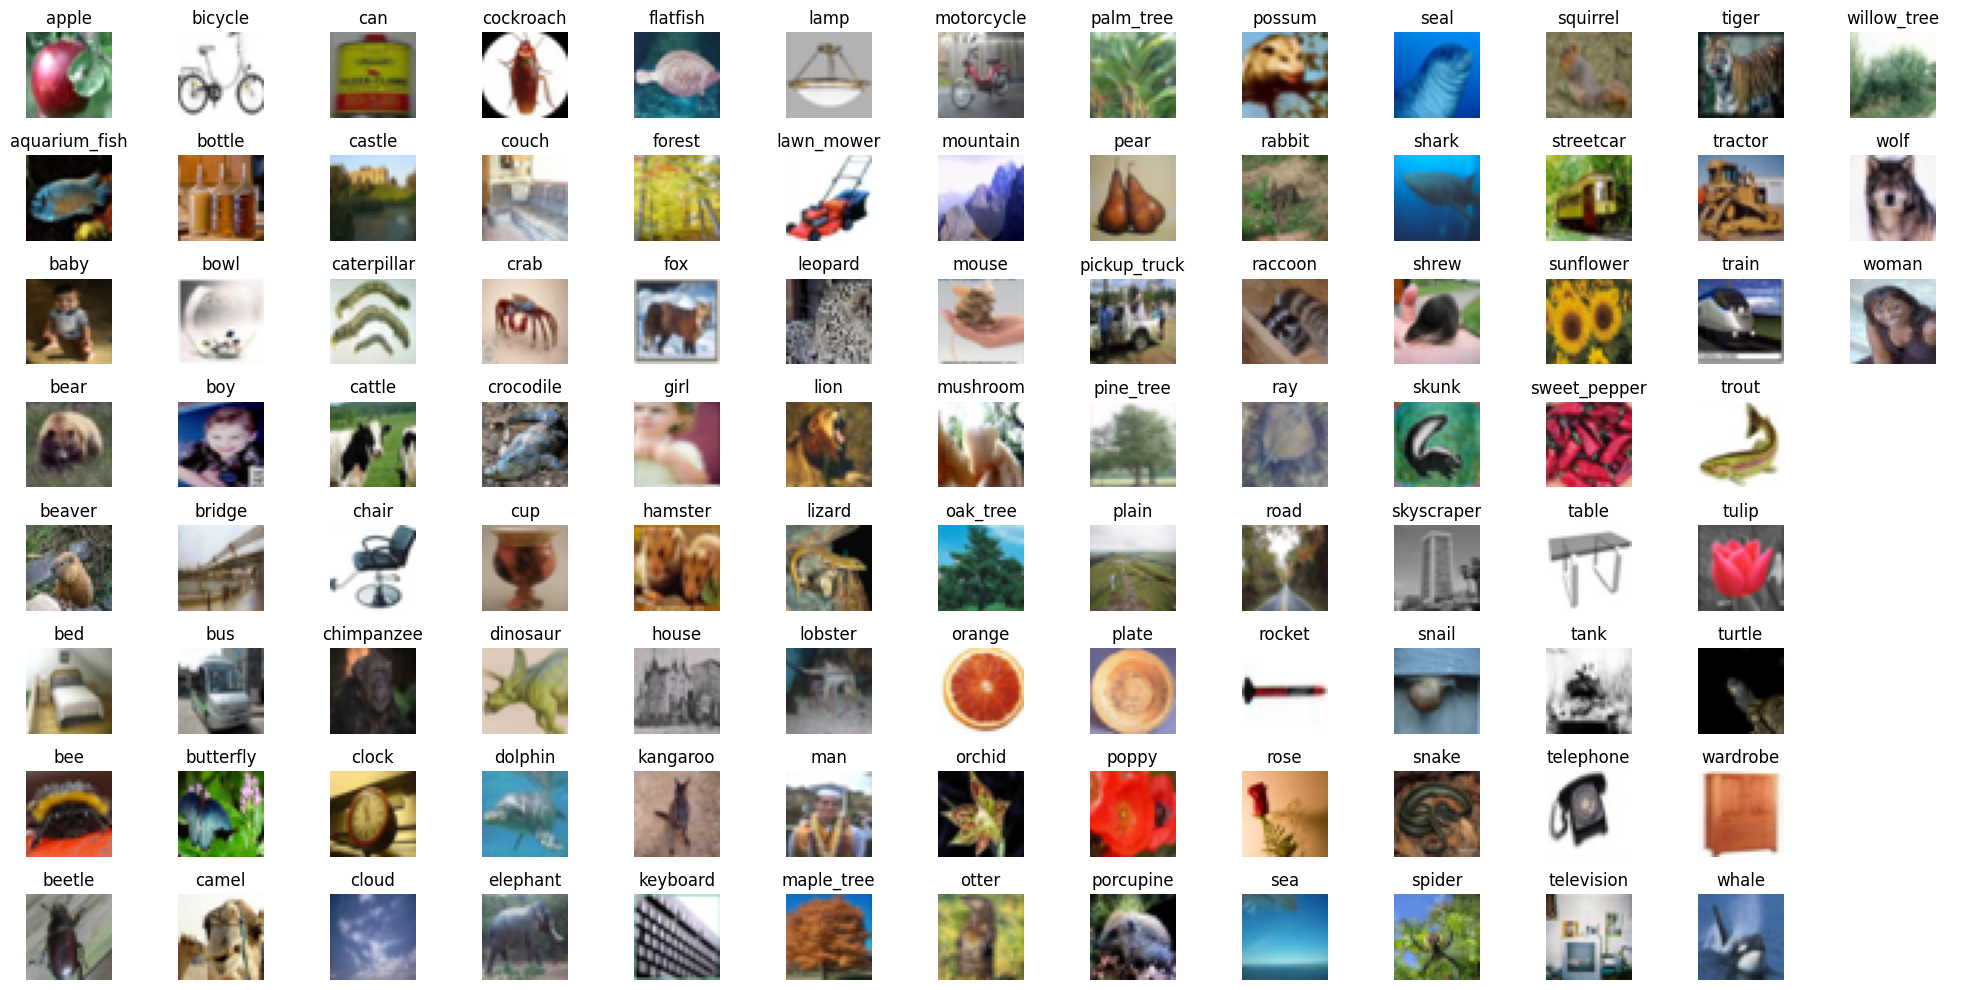

In [14]:
# TODO: Find One Image from Each Class
n_rows = 8
if (len(classes)% n_rows)!=0:
    n_cols = (len(classes)//n_rows) + 1
else:
    n_cols = (len(classes)//n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))

class_idx = 0
for col in range(n_cols):
    for row in range(n_rows):
        img_idx = torch.where(y_train == class_idx)[0][0]
        img = X_train[img_idx]


        # unnormalize
        img = img / 2 + 0.5         # from [-1,1] to [0,1]

        # CHW -> HWC
        img_to_show = img.permute(1, 2, 0)      # imshow wants HWC

        # Selecting the row and the col
        ax = axes[row, col]

        # plotting
        ax.imshow(img_to_show)

        ax.axis('off')

        ax.set_title(classes[class_idx])

        class_idx +=1
        if class_idx >= len(classes) - 1:
            break

    if class_idx >= len(classes) - 1:
            break
        

for idx in range(class_idx, n_rows * n_cols):
    row = idx % n_rows
    col = idx // n_rows
    axes[row, col].axis("off")

# TODO: Plot Images
plt.tight_layout()
plt.show()




### Modify Model

Change the final linear layer of the model according to the new number of classes And freeze all other layers.
- Do not forgot to move model to `device`

In [32]:
# Load Pretrained Model
model = BasicBlock(X_train.shape[1]).to(device)
X_train , y_train = X_train.to(device) , y_train.to(device)
X_valid , y_valid = X_valid.to(device) , y_valid.to(device)
X_test , y_test = X_test.to(device) , y_test.to(device)

checkpoint = torch.load(
    root / "Models" / "cifar10_Q1_checkpoint.pth",
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

epoch = checkpoint["epoch"]


# Freeze All Layers
for param in model.parameters():
    param.requires_grad = False

# Modify The Last Linear Layer
model.linear = nn.Linear(in_features=256, out_features=100)
for param in model.linear.parameters():
    param.requires_grad = True

# Move Model to Device
model = model.to(device)
print(model.parameters)


<bound method Module.parameters of BasicBlock(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (linear): Linear(in_features=256, out_features=100, bias=True)
)>


### Criterion & Optimizater

Define `criterion` and `optimizer` (Or `scheduler`)

In [33]:
# TODO: Define Loss and Optimizer
from torch import optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.linear.parameters())

### Train

Train the Model (Only Last Layer)

In [97]:
# TODO: Train The Model
train_dict , validation_dict = train_model(model , train_loader=trainloader,
                                           validation_loader=validationloader)


Epoch [1/50]: 100%|██████████| 625/625 [00:17<00:00, 34.91it/s, Loss=3.3595, Acc=0.1089]


Epoch [01/50] | Train Loss: 4.0512 | Train Acc: 0.1089 | Val Loss: 3.6550 | Val Acc: 0.1817


Epoch [2/50]: 100%|██████████| 625/625 [00:18<00:00, 33.75it/s, Loss=3.5895, Acc=0.1961]


Epoch [02/50] | Train Loss: 3.4995 | Train Acc: 0.1961 | Val Loss: 3.3529 | Val Acc: 0.2188


Epoch [3/50]: 100%|██████████| 625/625 [00:18<00:00, 33.46it/s, Loss=3.3669, Acc=0.2291]


...

Epoch [48/50] | Train Loss: 2.4940 | Train Acc: 0.3691 | Val Loss: 2.5826 | Val Acc: 0.3455


Epoch [49/50]: 100%|██████████| 625/625 [00:18<00:00, 33.25it/s, Loss=2.2500, Acc=0.3726]


Epoch [49/50] | Train Loss: 2.4864 | Train Acc: 0.3726 | Val Loss: 2.5718 | Val Acc: 0.3518


Epoch [50/50]: 100%|██████████| 625/625 [00:18<00:00, 32.98it/s, Loss=2.5916, Acc=0.3709]
                                                                                      c=0.3571]

Epoch [50/50] | Train Loss: 2.4843 | Train Acc: 0.3709 | Val Loss: 2.5571 | Val Acc: 0.3571


In [98]:
train_dict

{'loss': [4.051183795166016,
  3.4994945209503174,
  3.277321042251587,
  3.1497531692504883,
  3.062078835296631,
  2.999531121444702,
  2.953231797027588,
  2.9101641666412355,
  2.876947578048706,
  2.845335842514038,
  2.8244111167907713,
  2.8002437828063966,
  2.778571006011963,
  2.7586984832763672,
  2.7470853492736818,
  2.7286137966156008,
  2.7142947998046876,
  2.7020078117370607,
  2.689958320617676,
  2.675441233062744,
  2.668514067077637,
  2.6547811658859253,
  2.6472778228759766,
  2.638380076599121,
  2.6331997451782225,
  2.6193623516082765,
  2.61209414768219,
  2.6045190971374512,
  2.5937329822540285,
  2.587443255996704,
  2.5788016498565676,
  2.5733707904815675,
  2.5690231937408448,
  2.5640028158187866,
  2.556207199859619,
  2.55458805103302,
  2.5442135995864867,
  2.5395659301757814,
  2.534144167327881,
  2.5321263027191163,
  2.524977075958252,
  2.523271848487854,
  2.518282611846924,
  2.507632232093811,
  2.5017478813171388,
  2.498640219116211,
  2.

In [99]:
validation_dict

{'loss': [3.6549607112908817,
  3.352874321542728,
  3.1923706227806723,
  3.097466291136043,
  3.0329742203852175,
  2.9919607578569156,
  2.943131806744132,
  2.9132892250255416,
  2.885023888508985,
  2.849380954815324,
  2.8479246485764813,
  2.8123292072563415,
  2.8146815299987793,
  2.7874662845757356,
  2.782493694572692,
  2.7584369334445635,
  2.7609073933522414,
  2.7660088265777394,
  2.7402341882134698,
  2.712654497972719,
  2.7194205044181485,
  2.6922535501467952,
  2.6829841235640703,
  2.6925099108629165,
  2.6921711165434234,
  2.6844351716861605,
  2.660904729442232,
  2.6766600274735954,
  2.656245670500834,
  2.64735905683724,
  2.6447221837985286,
  2.631948663930225,
  2.6260848166836297,
  2.6234498358076546,
  2.6257947478324746,
  2.6204592300828096,
  2.617031082226213,
  2.6093859262527173,
  2.603502054123362,
  2.60238570164723,
  2.598541698638041,
  2.6171774211203216,
  2.579810991408719,
  2.5896697439205876,
  2.575527305056335,
  2.583155748950448,


In [100]:
import pandas as pd

train_df = pd.DataFrame(train_dict)
valid_df = pd.DataFrame(validation_dict)

In [101]:
result = pd.concat([train_df, valid_df], axis=1)
print(f"\t\tcifar100 loss and accuracy dict")
print(f"    training df \t\tvalidation df")
print(result)

		cifar100 loss and accuracy dict
    training df 		validation df
        loss  accuracy      loss  accuracy
0   4.051184  0.108850  3.654961    0.1817
1   3.499495  0.196075  3.352874    0.2188
2   3.277321  0.229075  3.192371    0.2444
3   3.149753  0.249125  3.097466    0.2600
4   3.062079  0.261450  3.032974    0.2635
5   2.999531  0.271225  2.991961    0.2716
6   2.953232  0.281175  2.943132    0.2769
7   2.910164  0.286200  2.913289    0.2840
8   2.876948  0.291750  2.885024    0.2923
9   2.845336  0.301025  2.849381    0.2985
10  2.824411  0.300800  2.847925    0.2972
11  2.800244  0.307400  2.812329    0.3046
12  2.778571  0.310250  2.814682    0.2994
13  2.758698  0.312375  2.787466    0.3088
14  2.747085  0.317700  2.782494    0.3117
15  2.728614  0.322175  2.758437    0.3101
16  2.714295  0.323350  2.760907    0.3091
17  2.702008  0.323200  2.766009    0.3130
18  2.689958  0.327750  2.740234    0.3161
19  2.675441  0.331175  2.712654    0.3242
20  2.668514  0.332700  2.71942

In [ ]:
train_df.to_excel(root/"Dataframes"/ 'cifar100_Q1_Classification_train_df.xlsx', index=False)
valid_df.to_excel(root/"Dataframes"/ 'cifar100_Q1_Classification_valid_df.xlsx', index=False)

### saving Model

In [103]:
# TODO: Save Model
checkpoint = {
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    "train_loss": train_dict["loss"][-1],
    "train_accuracy": train_dict["accuracy"][-1],

    "validation_loss": validation_dict["loss"][-1],
    "validation_accuracy": validation_dict["accuracy"][-1],
}

torch.save(
    checkpoint,
    root / "Models" / "cifar100_Q1_checkpoint.pth"
)

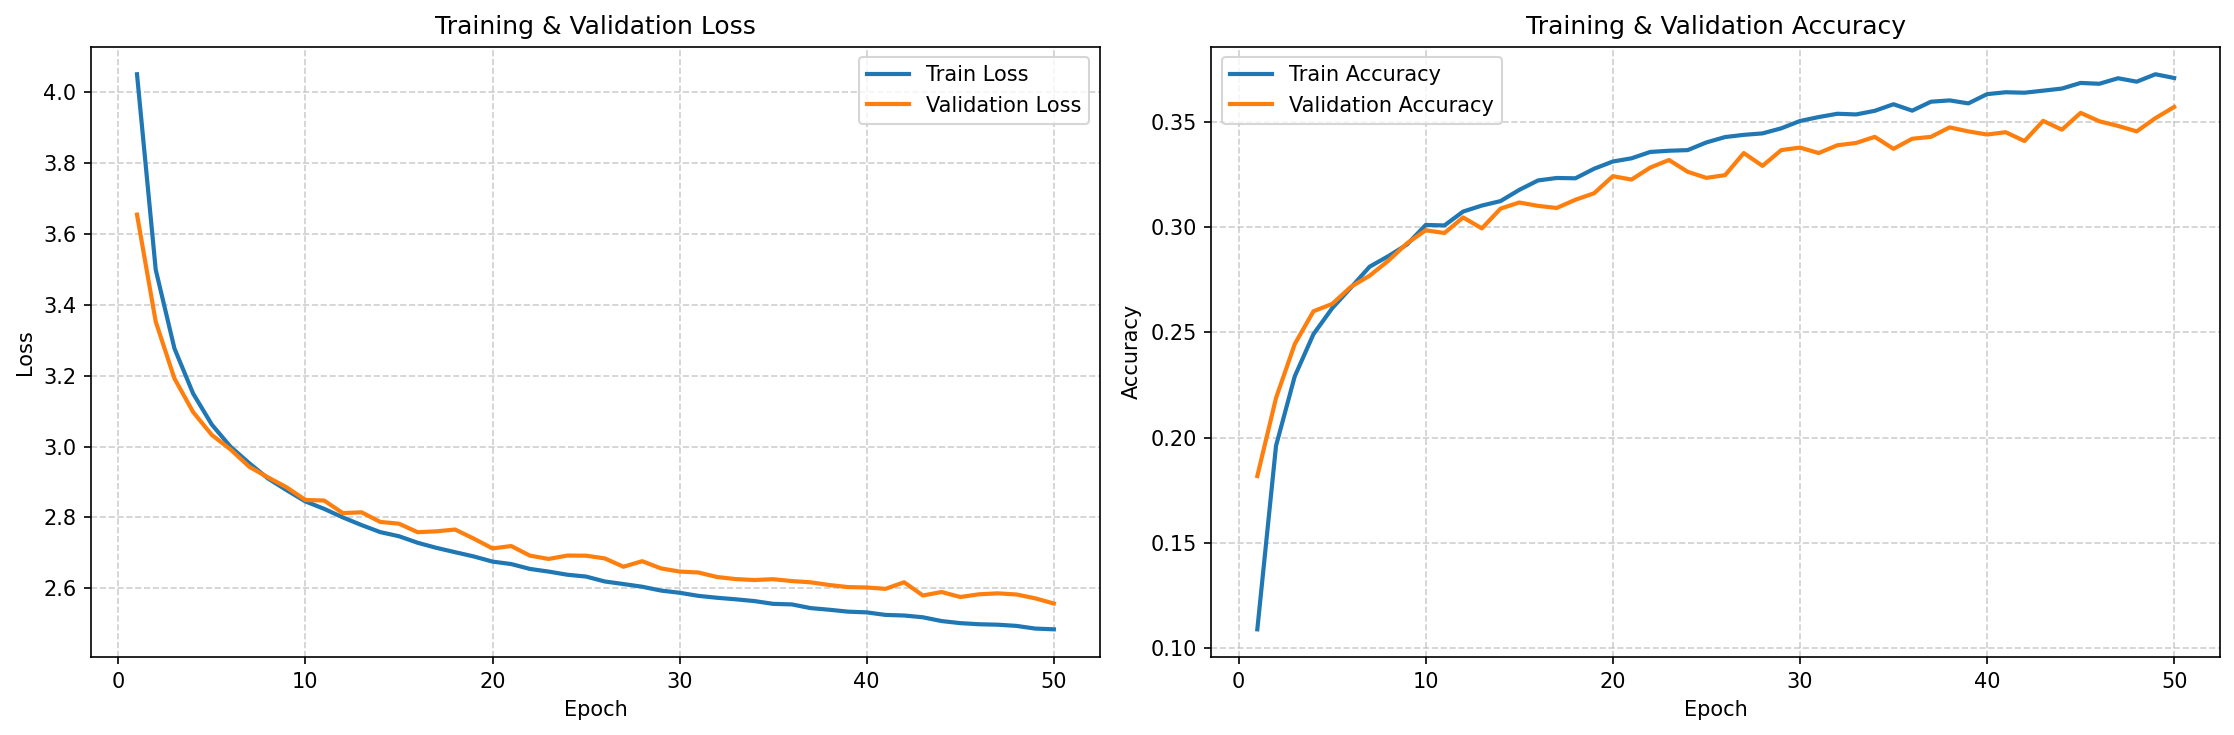

In [104]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_dict["loss"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ==========================
# Loss
# ==========================
ax[0].plot(epochs, train_df["loss"], label="Train Loss", linewidth=2)
ax[0].plot(epochs, valid_df["loss"], label="Validation Loss", linewidth=2)

ax[0].set_title("Training & Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, linestyle="--", alpha=0.6)
ax[0].legend()

# ==========================
# Accuracy
# ==========================
ax[1].plot(epochs, train_df["accuracy"], label="Train Accuracy", linewidth=2)
ax[1].plot(epochs, valid_df["accuracy"], label="Validation Accuracy", linewidth=2)

ax[1].set_title("Training & Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, linestyle="--", alpha=0.6)
ax[1].legend()

plt.tight_layout()
plt.show()

### Loaing the Model

In [23]:
model

BasicBlock(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (linear): Linear(in_features=256, out_features=10, bias=False)
)

In [35]:
import pandas as pd
train_df , valid_df = pd.read_excel(root / "Dataframes" /'cifar100_Q1_Classification_train_df.xlsx', index_col=0) ,pd.read_excel(root / "Dataframes" /'cifar100_Q1_Classification_valid_df.xlsx', index_col=0)

train_dict , valid_dict = train_df.to_dict() , valid_df.to_dict()
print(f"train_dict: {train_dict}")
print(f"valid_dict: {valid_dict}")


checkpoint = torch.load(
    root / "Models" / "cifar100_Q1_checkpoint.pth",
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

epoch = checkpoint["epoch"]

train_loss = checkpoint["train_loss"]
train_accuracy = checkpoint["train_accuracy"]

validation_loss = checkpoint["validation_loss"]
validation_accuracy = checkpoint["validation_accuracy"]

model.eval()

train_dict: {'loss': {0: 4.051183795166016, 1: 3.499494520950317, 2: 3.277321042251587, 3: 3.149753169250488, 4: 3.062078835296631, 5: 2.999531121444702, 6: 2.953231797027588, 7: 2.910164166641235, 8: 2.876947578048706, 9: 2.845335842514038, 10: 2.824411116790771, 11: 2.800243782806397, 12: 2.778571006011963, 13: 2.758698483276367, 14: 2.747085349273682, 15: 2.728613796615601, 16: 2.714294799804688, 17: 2.702007811737061, 18: 2.689958320617676, 19: 2.675441233062744, 20: 2.668514067077637, 21: 2.654781165885925, 22: 2.647277822875977, 23: 2.638380076599121, 24: 2.633199745178223, 25: 2.619362351608276, 26: 2.61209414768219, 27: 2.604519097137451, 28: 2.593732982254028, 29: 2.587443255996704, 30: 2.578801649856568, 31: 2.573370790481567, 32: 2.569023193740845, 33: 2.564002815818787, 34: 2.556207199859619, 35: 2.55458805103302, 36: 2.544213599586487, 37: 2.539565930175781, 38: 2.534144167327881, 39: 2.532126302719116, 40: 2.524977075958252, 41: 2.523271848487854, 42: 2.518282611846924, 4

BasicBlock(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (linear): Linear(in_features=256, out_features=100, bias=True)
)

### Test

Evaluate the Model on CIFAR-100 Test Set. 40% accuracy is sufficient.


In [39]:
model

BasicBlock(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (linear): Linear(in_features=256, out_features=100, bias=True)
)

In [43]:
testloader

In [44]:
# TODO: Evaluate Model on CIFAR100
model.eval()
test_dict = {
    "loss":[],
    "accuracy":[]
}
test_epoch_loss = 0.0
test_correct = 0
test_total = 0
for batch_x_test , batch_y_test in testloader:
            
    batch_x_test , batch_y_test = batch_x_test.to(device) , batch_y_test.to(device)

    test_outputs = model(batch_x_test)

    test_loss = criterion(test_outputs, batch_y_test)

    test_epoch_loss += test_loss.item()

    test_pred = test_outputs.argmax(dim=1)
    test_correct += (test_pred == batch_y_test).sum().item()
    test_total += batch_y_test.size(0)

    avg_test_loss = test_epoch_loss / len(testloader)
    test_dict["loss"].append(avg_test_loss)
    test_accuracy = test_correct / test_total
    test_dict["accuracy"].append(test_accuracy)

# TODO: Print Accuracy

test_df = pd.DataFrame(test_dict)
test_df.to_excel(root / "Dataframes" /'cifar100_Q1_Classification_test_df.xlsx' , index=False)
test_df


,loss,accuracy
0,0.015693,0.468750
1,0.029723,0.468750
2,0.045355,0.458333
3,0.060191,0.445312
4,0.076821,0.418750
...,...,...
152,2.466524,0.364481
153,2.481868,0.364550
154,2.497634,0.364718
155,2.513472,0.364683


### Question
You might think that 40% accuracy is quite low. However, first of all, consider that the classification is done over 100 classes. The accuracy of a random model in this case is 1%. Also, we only changed one linear layer of the model, and the rest of the weights remained unchanged. What do you think is the reason the model can achieve a reasonably good generalization ability on a completely new dataset with just the change of one linear layer at the end?

Answer:  
I believe the relatively good performance on CIFAR-100 is mainly due to the transferability of the learned feature representations.

The convolutional layers trained on CIFAR-10 have learned general visual features such as edges, corners, textures, and simple object parts. Although CIFAR-100 contains ten times more classes and is considerably more diverse, many of these classes still share similar low-level and mid-level visual patterns with those in CIFAR-10.

Some classes exhibit highly overlapping feature distributions, others share only part of their visual characteristics, while a few classes are almost entirely different from those in the source dataset. Consequently, the frozen feature extractor remains useful for a significant portion of the new dataset, enabling the newly initialized classification layer to achieve reasonable accuracy without fine-tuning the backbone.

### Visualize incorrectly predicted samples from testset

Visualize *10* random images from testset that are incorrectly predicted by the model

In [45]:
def get_misclassified_examples(model, test_loader,device='cuda'):
    model.eval()
        
    misclassified_indices = []
    actual_labels = []
    predicted_labels = []
    global_idx = 0
    with torch.no_grad():
        for batch_x_test , batch_y_test in testloader:
            batch_x_test , batch_y_test = batch_x_test.to(device) , batch_y_test.to(device)  
            outputs = model(batch_x_test)
            test_pred = outputs.argmax(dim=1)  
            for i in range(len(batch_y_test)):
                actual = batch_y_test[i].item()
                predicted = test_pred[i].item()

                if actual != predicted:
                        misclassified_indices.append(global_idx)
                        actual_labels.append(actual)
                        predicted_labels.append(predicted)

                global_idx += 1

    wrong_test_df = pd.DataFrame(
        {
            'Image_Index': misclassified_indices,
            'Actual_Class': actual_labels,
            'Predicted_Class': predicted_labels
        }
        )
    return wrong_test_df

In [46]:
df_errors = get_misclassified_examples(model, testloader)

In [47]:
df_errors

,Image_Index,Actual_Class,Predicted_Class
0,2,72,15
1,3,51,89
2,5,92,6
3,6,15,90
4,7,14,88
...,...,...,...
6349,9991,27,30
6350,9994,50,97
6351,9996,14,38
6352,9997,51,75


In [48]:
df_errors["Image_Index"].loc[1]

np.int64(3)

In [49]:
X_test.shape

torch.Size([10000, 3, 32, 32])

In [50]:
X_test_visualize = X_test.to('cpu') # cuda version of test set can not be passed to numpy

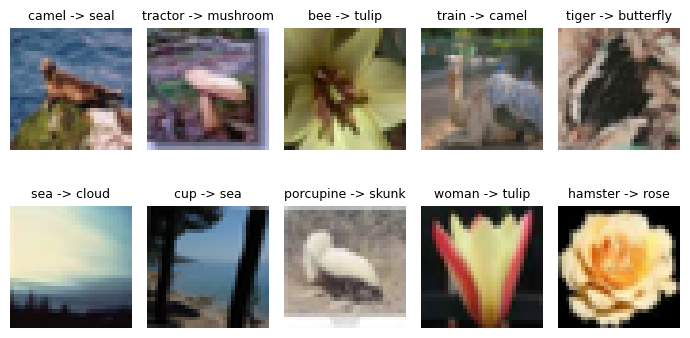

In [60]:
# TODO: Plot Samples with Wrong Predicted Classes

n_rows = 2 
n_cols = 5
total = n_rows * n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 4))
axes_flat = axes.flat
for example in range(total):
    ax = axes_flat[example]
    img = X_test_visualize[df_errors["Image_Index"].loc[example]]

    # unnormalize
    img = img / 2 + 0.5         # from [-1,1] to [0,1]

    img = torch.clamp(img, 0, 1)
    # CHW -> HWC
    img_to_show = img.permute(1, 2, 0)      # imshow wants HWC

    # plotting
    ax.imshow(img_to_show)

    ax.axis('off')

    ax.set_title(
        f"{classes[df_errors['Predicted_Class'].loc[example]]} -> {classes[df_errors['Actual_Class'].loc[example]]}"
    ,fontsize=9)

plt.tight_layout()
plt.show()


### Plot accuracy for each class

Plot accuracy of model on testset for each class.

In [64]:
def get_right_classified_examples(model, test_loader,device='cuda'):
    model.eval()
        
    right_classified_indices = []
    actual_labels = []
    predicted_labels = []
    global_idx = 0
    with torch.no_grad():
        for batch_x_test , batch_y_test in testloader:
            batch_x_test , batch_y_test = batch_x_test.to(device) , batch_y_test.to(device)  
            outputs = model(batch_x_test)
            test_pred = outputs.argmax(dim=1)  
            for i in range(len(batch_y_test)):
                actual = batch_y_test[i].item()
                predicted = test_pred[i].item()

                if actual == predicted:
                        right_classified_indices.append(global_idx)
                        actual_labels.append(actual)
                        predicted_labels.append(predicted)

                global_idx += 1

    right_test_df = pd.DataFrame(
        {
            'Image_Index': right_classified_indices,
            'Actual_Class': actual_labels,
            'Predicted_Class': predicted_labels
        }
        )
    return right_test_df

In [65]:
df_right_test = get_right_classified_examples(model, testloader)
df_right_test

,Image_Index,Actual_Class,Predicted_Class
0,0,49,49
1,1,33,33
2,4,71,71
3,9,0,0
4,12,81,81
...,...,...,...
3641,9990,75,75
3642,9992,16,16
3643,9993,30,30
3644,9995,83,83


In [79]:
df_right_test[df_right_test["Predicted_Class"]==0]

,Image_Index,Actual_Class,Predicted_Class
3,9,0,0
53,113,0,0
100,226,0,0
157,377,0,0
186,484,0,0
...,...,...,...
3339,9221,0,0
3400,9387,0,0
3591,9849,0,0
3598,9872,0,0


In [100]:
def class_acc(df_right):
    class_right_answers = {}
    
    for i in range(len(classes)):
            class_right_answers[i] = []
            filterd_df = df_right[df_right["Predicted_Class"]==i]
            for img_idx in filterd_df["Image_Index"].values:
                  class_right_answers[i].append(img_idx)
    
    return class_right_answers


In [102]:
test_right_answers_dict = class_acc(df_right_test)
test_right_answers_dict

{0: [np.int64(9),
  np.int64(113),
  np.int64(226),
  np.int64(377),
  np.int64(484),
  np.int64(655),
  np.int64(1014),
  np.int64(1027),
  np.int64(1136),
  np.int64(1308),
  np.int64(1373),
  np.int64(1738),
  np.int64(1925),
  np.int64(2375),
  np.int64(2488),
  np.int64(2512),
  np.int64(2648),
  np.int64(2960),
  np.int64(2988),
  np.int64(3005),
  np.int64(3066),
  np.int64(3510),
  np.int64(3518),
  np.int64(3712),
  np.int64(3725),
  np.int64(3751),
  np.int64(3752),
  np.int64(3775),
  np.int64(4100),
  np.int64(4144),
  np.int64(4289),
  np.int64(4340),
  np.int64(4433),
  np.int64(4640),
  np.int64(4760),
  np.int64(4965),
  np.int64(5306),
  np.int64(5370),
  np.int64(5496),
  np.int64(5675),
  np.int64(5679),
  np.int64(5731),
  np.int64(5807),
  np.int64(5885),
  np.int64(5900),
  np.int64(5913),
  np.int64(6253),
  np.int64(6415),
  np.int64(6806),
  np.int64(6922),
  np.int64(7219),
  np.int64(7365),
  np.int64(7638),
  np.int64(7655),
  np.int64(8045),
  np.int64(8131

In [ ]:
# TODO: Calculate Accuracy for Each Class
class_acc_each = {}
for i in test_right_answers_dict.keys():
    class_acc_each[i] = []
    total = sum(y_test == i).item()
    total_right = len(test_right_answers_dict[i])
    class_acc_each[i] = round((total_right / total) , 3)
    

In [127]:
class_acc_each

{0: 0.69,
 1: 0.33,
 2: 0.25,
 3: 0.26,
 4: 0.16,
 5: 0.35,
 6: 0.27,
 7: 0.07,
 8: 0.44,
 9: 0.31,
 10: 0.3,
 11: 0.34,
 12: 0.43,
 13: 0.26,
 14: 0.31,
 15: 0.19,
 16: 0.37,
 17: 0.63,
 18: 0.41,
 19: 0.4,
 20: 0.52,
 21: 0.58,
 22: 0.24,
 23: 0.53,
 24: 0.53,
 25: 0.22,
 26: 0.12,
 27: 0.3,
 28: 0.31,
 29: 0.2,
 30: 0.52,
 31: 0.32,
 32: 0.18,
 33: 0.43,
 34: 0.29,
 35: 0.05,
 36: 0.5,
 37: 0.33,
 38: 0.28,
 39: 0.3,
 40: 0.26,
 41: 0.49,
 42: 0.34,
 43: 0.37,
 44: 0.13,
 45: 0.19,
 46: 0.19,
 47: 0.42,
 48: 0.7,
 49: 0.62,
 50: 0.13,
 51: 0.25,
 52: 0.64,
 53: 0.74,
 54: 0.55,
 55: 0.01,
 56: 0.34,
 57: 0.39,
 58: 0.73,
 59: 0.34,
 60: 0.75,
 61: 0.15,
 62: 0.37,
 63: 0.42,
 64: 0.2,
 65: 0.11,
 66: 0.26,
 67: 0.29,
 68: 0.6,
 69: 0.55,
 70: 0.34,
 71: 0.7,
 72: 0.1,
 73: 0.33,
 74: 0.19,
 75: 0.52,
 76: 0.64,
 77: 0.16,
 78: 0.16,
 79: 0.27,
 80: 0.12,
 81: 0.43,
 82: 0.65,
 83: 0.24,
 84: 0.29,
 85: 0.48,
 86: 0.29,
 87: 0.59,
 88: 0.46,
 89: 0.57,
 90: 0.43,
 91: 0.36,
 92: 0.26

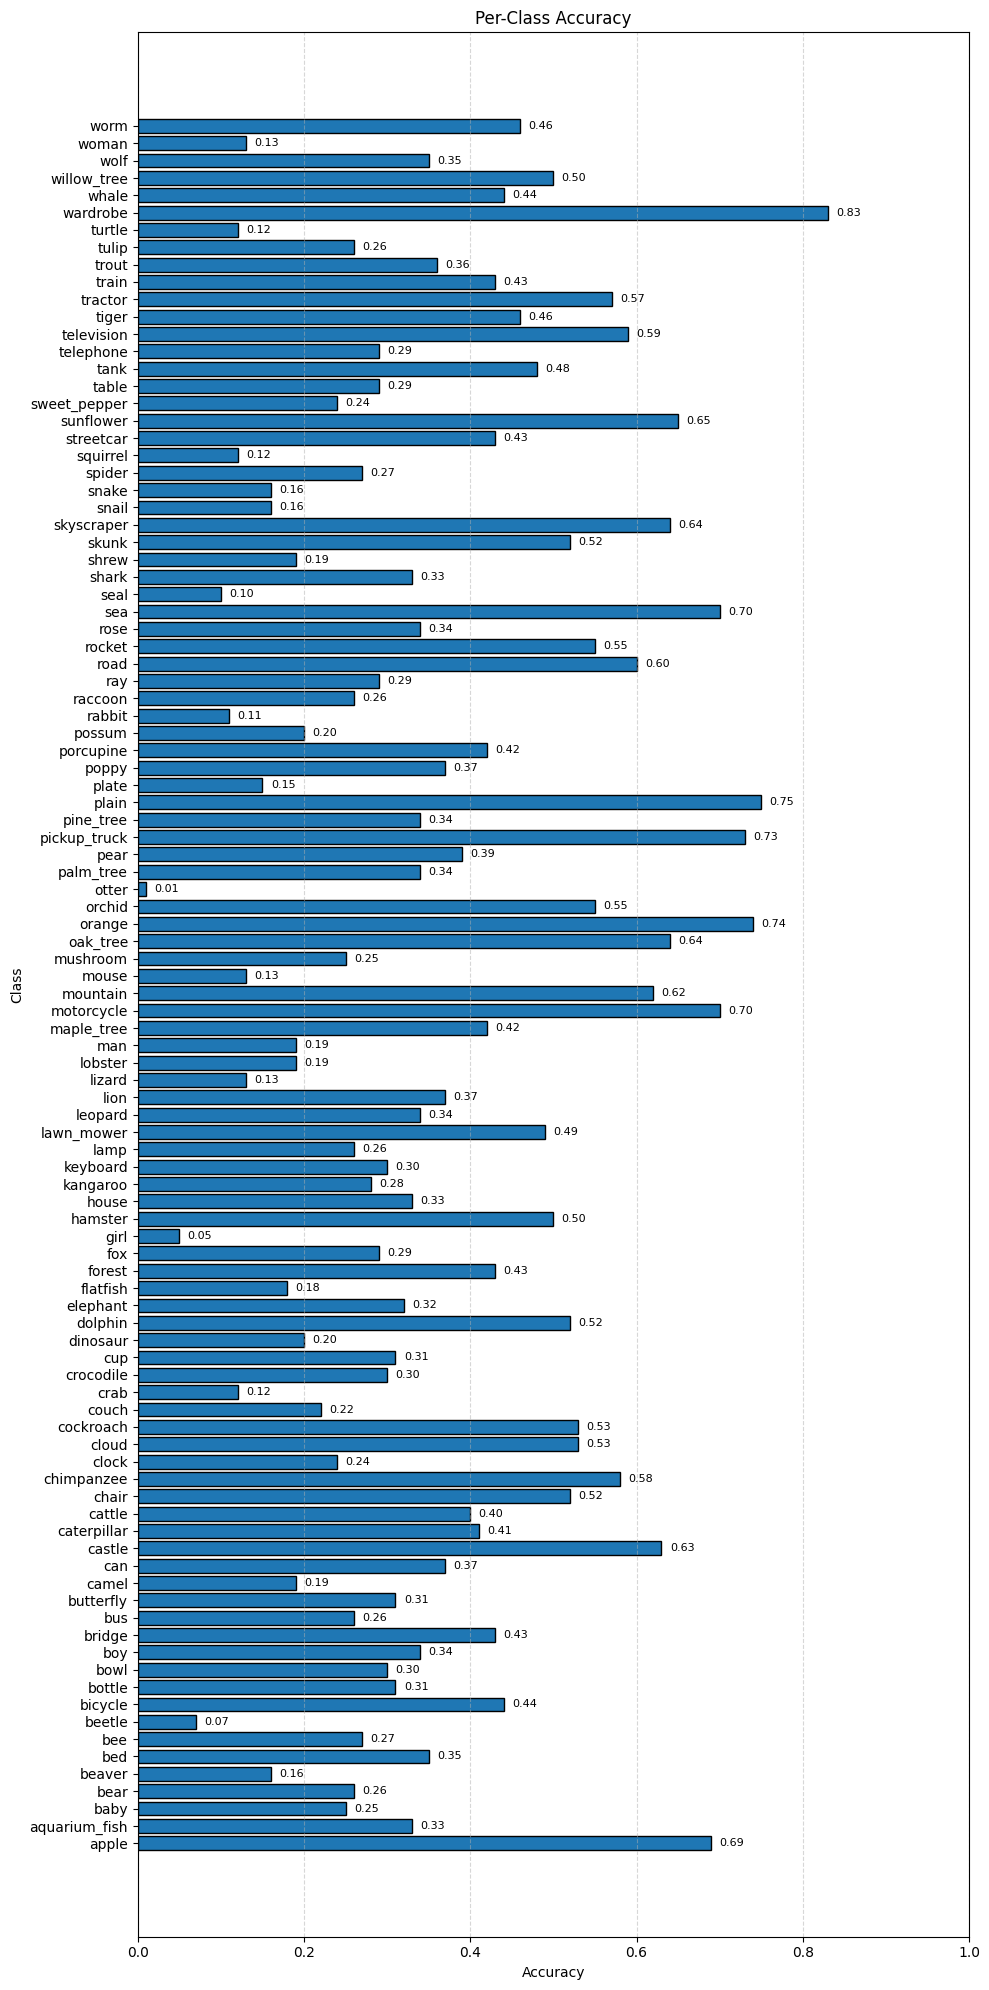

In [129]:
# TODO: Plot Class-Wise Accuracy
plt.figure(figsize=(10, 20))

bars = plt.barh(
    classes,
    class_acc_each.values(),
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center",
        fontsize=8
    )

plt.xlim(0, 1)

plt.xlabel("Accuracy")
plt.ylabel("Class")
plt.title("Per-Class Accuracy")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### The classes with the best and worst accuracy

Based on the results from the previous section, obtain the 5 classes with the best accuracy and the 5 classes with the worst accuracy on the testset, and display one sample from each of them.

Here's the Top 5 Best Performing Classes
      class_name  accuracy
94      wardrobe      0.83
60         plain      0.75
53        orange      0.74
58  pickup_truck      0.73
48    motorcycle      0.70

Here's the Top 5 Worst Performing Classes
   class_name  accuracy
55      otter      0.01
35       girl      0.05
7      beetle      0.07
72       seal      0.10
65     rabbit      0.11


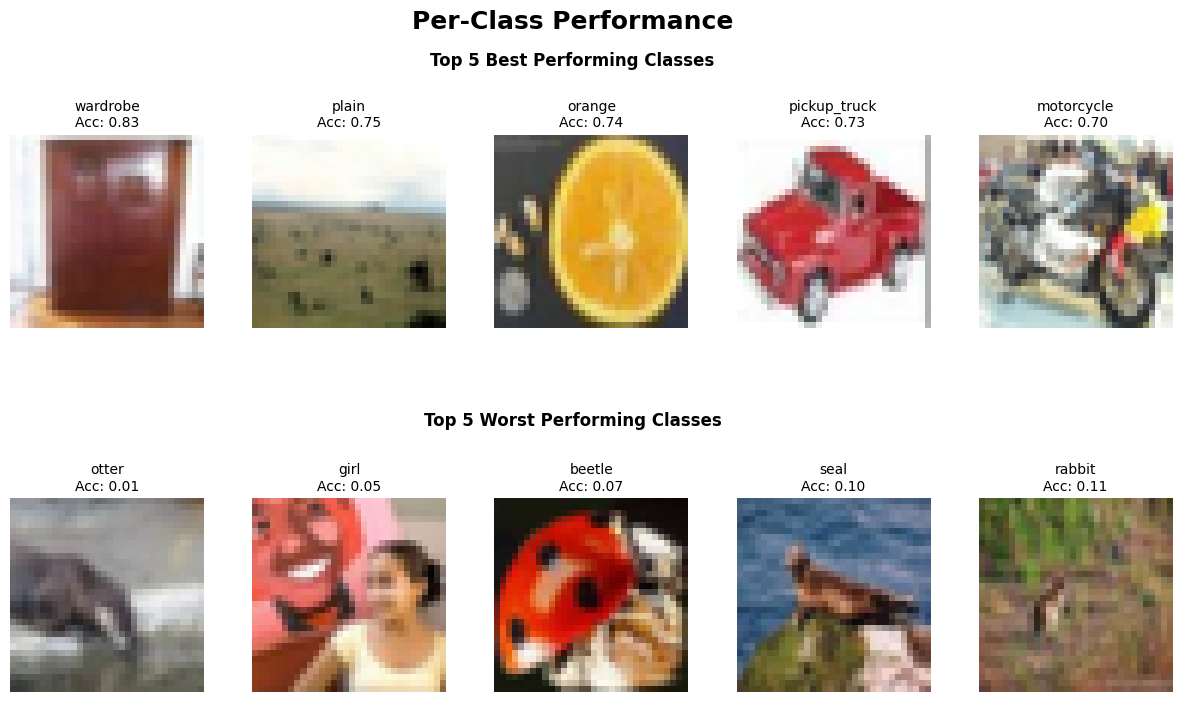

In [187]:
# TODO: Find Top 5 Best and Worst Performing Classes

class_acc_each_df = pd.DataFrame({
    "class_name": [classes[i] for i in class_acc_each.keys()],
    "accuracy": list(class_acc_each.values())
})

best_5 = class_acc_each_df.sort_values(
    by="accuracy",
    ascending=False
).head(5)

worst_5 = class_acc_each_df.sort_values(
    by="accuracy",
    ascending=True
).head(5)

print("Here's the Top 5 Best Performing Classes")
print(best_5)

print("\nHere's the Top 5 Worst Performing Classes")
print(worst_5)


# Plot one sample image from each class

n_rows = 2
n_cols = 5

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 8)
)

fig.suptitle(
    "Per-Class Performance",
    fontsize=18,
    fontweight="bold"
)

row_classes = [
    best_5["class_name"].tolist(),
    worst_5["class_name"].tolist()
]

for row in range(n_rows):
    for col in range(n_cols):

        ax = axes[row, col]

        img_class = row_classes[row][col]
        img_class_idx = classes.index(img_class)

        img_idx = torch.where(y_test == img_class_idx)[0][0].item()

        img = X_test_visualize[img_idx]

        # Unnormalize: [-1, 1] -> [0, 1]
        img = img / 2 + 0.5
        img = torch.clamp(img, 0, 1)

        # CHW -> HWC
        img_to_show = img.permute(1, 2, 0).cpu()

        ax.imshow(img_to_show)
        ax.axis("off")
        ax.set_title(
            f"{img_class}\nAcc: {class_acc_each[img_class_idx]:.2f}",
            fontsize=10
        )

fig.text(
    0.5,
    0.91,
    "Top 5 Best Performing Classes",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

fig.text(
    0.5,
    0.46,
    "Top 5 Worst Performing Classes",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.subplots_adjust(
    top=0.84,
    hspace=0.65,
    wspace=0.25
)

plt.show()

### Question
What do you think is the reason for the significant accuracy difference between different classes? What differences do you observe between the classes with the best and worst accuracy? Can you provide an analysis of the results and relate them to the model’s feature space?

Answer:

I think the main reason for the difference in accuracy is that some classes are much easier to distinguish than others. Classes with unique shapes or textures are classified more accurately, while classes that look visually similar to others are more likely to be confused.

This can also be explained by the feature space. The best-performing classes usually form more compact and well-separated clusters, making them easier for the classifier to recognize. On the other hand, the worst-performing classes have more overlapping feature representations, so the decision boundaries become less clear and the model makes more mistakes.

Overall, the quality of the learned feature space has a strong impact on the classification accuracy of each class.